# OHL Attendance

```bash
pip install pandas numpy matplotlib seaborn scikit-learn scipy jupyter

In [352]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for professional plots
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

In [353]:
# AUTO-SAVE SETUP FOR BAR CHARTS

import os

# Create bar_charts folder if it doesn't exist
if not os.path.exists('bar_charts'):
    os.makedirs('bar_charts')
    print("Created 'bar_charts' folder")

def save_chart(filename, fig=None, dpi=150, bbox_inches='tight'):
    """
    Save the current figure to bar_charts folder.
    Use this after plt.tight_layout() and before plt.show()
    
    Example:
        plt.tight_layout()
        save_chart('article_impact_by_category')
        plt.show()
    """
    full_path = f'bar_charts/{filename}.png'
    if fig:
        fig.savefig(full_path, dpi=dpi, bbox_inches=bbox_inches)
    else:
        plt.savefig(full_path, dpi=dpi, bbox_inches=bbox_inches)
    print(f"✓ Chart saved: {full_path}")

print("Auto-save setup complete. Use: save_chart('filename') after each chart")

Created 'bar_charts' folder
Auto-save setup complete. Use: save_chart('filename') after each chart


In [354]:
# ============================================================================
# 1. CLUB NEWS & MEDIA ATTENTION - Belga Press Articles
# ============================================================================
print("\n1. CLUB NEWS & MEDIA ATTENTION - Belga Press Articles")

# First load match data to get match dates and opponents
try:
    match_df = pd.read_csv('data/gold_match.csv', on_bad_lines='skip')
    match_df.columns = match_df.columns.str.strip()
    match_df['match_date'] = pd.to_datetime(match_df['match_date'], errors='coerce')
    match_df = match_df[match_df['is_home_match'] == True].copy()
    print(f"Loaded match data: {len(match_df)} home matches")
    
    # Create match lookup
    match_lookup = match_df[['match_id', 'match_date', 'away_team', 'tickets_scanned']].copy()
    match_lookup = match_lookup.sort_values('match_date').reset_index(drop=True)
    print(f"Match lookup: {len(match_lookup)} matches")
    overall_avg = match_lookup['tickets_scanned'].mean()
    print(f"Overall average attendance: {overall_avg:.0f} fans")
    
except Exception as e:
    print(f"Error loading match data: {e}")
    match_df = pd.DataFrame()
    match_lookup = pd.DataFrame()
    overall_avg = 0

# Load articles data with special handling
try:
    articles_df = pd.read_csv('data/gold_belga_press_articles.csv', 
                               on_bad_lines='skip', 
                               quoting=1, 
                               encoding='utf-8')
    print(f"Loaded {len(articles_df)} articles")
except Exception as e:
    print(f"Error loading articles: {e}")
    articles_df = pd.DataFrame()

if len(articles_df) > 0:
    # Clean column names
    articles_df.columns = articles_df.columns.str.strip()
    
    # Convert date
    if 'date' in articles_df.columns:
        articles_df['date'] = pd.to_datetime(articles_df['date'], errors='coerce')
        articles_df = articles_df.dropna(subset=['date'])
        print(f"Articles with valid dates: {len(articles_df)}")


1. CLUB NEWS & MEDIA ATTENTION - Belga Press Articles
Loaded match data: 71 home matches
Match lookup: 71 matches
Overall average attendance: 6862 fans
Loaded 48680 articles
Articles with valid dates: 48677


In [355]:
# Match articles to upcoming matches
print("\nMATCHING ARTICLES TO UPCOMING MATCHES")

def find_next_match(article_date):
    if len(match_lookup) == 0:
        return None
    future_matches = match_lookup[match_lookup['match_date'] > article_date]
    if len(future_matches) > 0:
        return future_matches.iloc[0]
    return None

article_match_pairs = []

if len(articles_df) > 0 and len(match_lookup) > 0:
    for idx, article in articles_df.iterrows():
        article_date = article['date']
        next_match = find_next_match(article_date)
        
        if next_match is not None:
            article_match_pairs.append({
                'article_id': article.get('article_id', idx),
                'article_date': article_date,
                'title': article.get('title', ''),
                'lead': article.get('lead', ''),
                'match_id': next_match['match_id'],
                'match_date': next_match['match_date'],
                'opponent': next_match['away_team'],
                'days_before': (next_match['match_date'] - article_date).days
            })

article_matches_df = pd.DataFrame(article_match_pairs)
print(f"Articles matched to upcoming matches: {len(article_matches_df)}")


MATCHING ARTICLES TO UPCOMING MATCHES
Articles matched to upcoming matches: 48454


In [356]:
# Filter articles that mention the opponent
print("\nFILTERING BY OPPONENT MENTION")

def mentions_opponent(title, lead, opponent):
    text = str(title).lower() + " " + str(lead).lower()
    opponent_lower = str(opponent).lower()
    return opponent_lower in text and opponent_lower not in ['nan', 'none', '']

# Initialize variables
relevant_articles = pd.DataFrame()
article_matches_df = pd.DataFrame() if 'article_matches_df' not in locals() else article_matches_df

if len(article_matches_df) > 0:
    article_matches_df['mentions_opponent'] = article_matches_df.apply(
        lambda x: mentions_opponent(x['title'], x['lead'], x['opponent']), axis=1
    )
    
    relevant_articles = article_matches_df[article_matches_df['mentions_opponent'] == True].copy()
    print(f"Articles that mention the specific opponent: {len(relevant_articles)}")
    
    if len(relevant_articles) > 0:
        print("\nSAMPLE ARTICLES MENTIONING OPPONENT:")
        for idx, row in relevant_articles.head(5).iterrows():
            print(f"  {row['article_date'].date()} -> {row['match_date'].date()} vs {row['opponent']}: {row['title'][:50]}...")
else:
    print("No articles matched to matches")


FILTERING BY OPPONENT MENTION
Articles that mention the specific opponent: 3810

SAMPLE ARTICLES MENTIONING OPPONENT:
  2023-01-05 -> 2023-01-08 vs Kortrijk: Mathieu Maertens (OHL): “Sportieve revanche tegen ...
  2023-01-05 -> 2023-01-08 vs Kortrijk: Stjepan Loncar, werkmier op het middenveld van KV ...
  2023-01-05 -> 2023-01-08 vs Kortrijk: Overzicht wintertransfers 1A: wie komt, wie gaat?...
  2023-01-06 -> 2023-01-08 vs Kortrijk: Kortrijk-coach Bernd Storck rekent op aanwinsten o...
  2023-01-06 -> 2023-01-08 vs Kortrijk: ''Fans hebben beste Stjepan Loncar nog niet gezien...


In [357]:
# Categorize articles by content type
print("\nCATEGORIZING ARTICLES BY CONTENT")

# Dutch keywords for different categories
dutch_keywords = {
    'Coach News': ['coach', 'trainer', 'manager', 'vanhaezebrouck', 'hein', 'bryce', 'hoofdtrainer', 'assistent', 'ontslag', 'aangesteld'],
    'Transfer News': ['transfer', 'versterking', 'contract', 'nieuwe speler', 'aankomst', 'vertrek', 'tekent', 'komt over', 'verlaat', 'huur', 'transfervrij', 'binnen'],
    'Match Performance': ['winst', 'overwinning', 'nederlaag', 'verlies', 'gelijkspel', 'verslag', 'samenvatting', 'score', 'uitslag', 'resultaat', 'zege', 'goals'],
    'Player News': ['speler', 'blessure', 'terugkeer', 'comeback', 'geschorst', 'beschikbaar', 'fit', 'herstel', 'geblesseerd', 'selectie', 'opstelling'],
    'Media Coverage': ['interview', 'pers', 'media', 'statement', 'reactie', 'commentaar', 'persconferentie', 'journalist'],
    'Match Preview': ['voorbeschouwing', 'preview', 'aanloop', 'vooruitblik', 'komende wedstrijd', 'tegenstander', 'tactiek', 'analyse'],
    'Club News': ['club', 'stadion', 'fans', 'supporters', 'ticket', 'seizoen', 'den dreef', 'jeugd', 'academie'],
    'Injury News': ['blessure', 'geblesseerd', 'knie', 'enkel', 'spier', 'hamstring', 'operatie', 'revalidatie', 'valt uit']
}

def categorize_article(title, lead):
    text = str(title).lower() + " " + str(lead).lower()
    for category, keywords in dutch_keywords.items():
        if any(keyword in text for keyword in keywords):
            return category
    return 'Other News'

def has_home_mention(title, lead):
    text = str(title).lower() + " " + str(lead).lower()
    home_keywords = ['ohl', 'oud heverlee', 'leuven', 'den dreef', 'oh leuven']
    return any(keyword in text for keyword in home_keywords)

if len(relevant_articles) > 0:
    relevant_articles['category'] = relevant_articles.apply(
        lambda x: categorize_article(x['title'], x['lead']), axis=1
    )
    
    relevant_articles['has_home_mention'] = relevant_articles.apply(
        lambda x: has_home_mention(x['title'], x['lead']), axis=1
    )
    
    print("\nARTICLE CATEGORIES:")
    category_counts = relevant_articles['category'].value_counts()
    for cat, count in category_counts.items():
        print(f"  {cat}: {count} articles")
    
    print("\nHOME TEAM MENTIONS:")
    home_count = relevant_articles['has_home_mention'].sum()
    print(f"  Articles mentioning OH Leuven: {home_count}")
else:
    print("No relevant articles to categorize")


CATEGORIZING ARTICLES BY CONTENT

ARTICLE CATEGORIES:
  Match Performance: 837 articles
  Club News: 822 articles
  Coach News: 666 articles
  Other News: 643 articles
  Transfer News: 386 articles
  Player News: 301 articles
  Media Coverage: 79 articles
  Match Preview: 51 articles
  Injury News: 25 articles

HOME TEAM MENTIONS:
  Articles mentioning OH Leuven: 3480


In [358]:
# Count articles per match
print("\nCOUNTING ARTICLES PER MATCH")

# Initialize variables
article_counts_df = pd.DataFrame()

if len(relevant_articles) > 0 and len(match_lookup) > 0:
    match_article_counts = []
    
    for match_id in match_lookup['match_id'].unique():
        match_articles = relevant_articles[relevant_articles['match_id'] == match_id]
        
        row_data = {'match_id': match_id}
        
        # Count by category
        for category in relevant_articles['category'].unique():
            col_name = f'art_{category.replace(" ", "_")}'
            row_data[col_name] = len(match_articles[match_articles['category'] == category])
        
        # Count by mention type
        row_data['art_home_mention'] = len(match_articles[match_articles['has_home_mention'] == True])
        row_data['art_opponent_only'] = len(match_articles[(match_articles['has_home_mention'] == False) & (match_articles['mentions_opponent'] == True)])
        row_data['art_both_teams'] = len(match_articles[(match_articles['has_home_mention'] == True) & (match_articles['mentions_opponent'] == True)])
        row_data['art_total'] = len(match_articles)
        
        match_article_counts.append(row_data)
    
    article_counts_df = pd.DataFrame(match_article_counts).fillna(0)
    
    for col in article_counts_df.columns:
        if col != 'match_id':
            article_counts_df[col] = article_counts_df[col].astype(int)
    
    print(f"Matches with articles: {len(article_counts_df[article_counts_df['art_total'] > 0])}")
    print(f"Total articles counted: {article_counts_df['art_total'].sum()}")
else:
    print("No article data to count")


COUNTING ARTICLES PER MATCH
Matches with articles: 64
Total articles counted: 3810


In [359]:
# Merge with attendance data
print("\nMERGING WITH ATTENDANCE DATA")

if len(match_lookup) == 0:
    print("No match data available")
    df_with_articles = pd.DataFrame()
else:
    if len(article_counts_df) > 0:
        df_with_articles = match_lookup.merge(article_counts_df, on='match_id', how='left')
        for col in article_counts_df.columns:
            if col != 'match_id':
                df_with_articles[col] = df_with_articles[col].fillna(0).astype(int)
    else:
        df_with_articles = match_lookup.copy()
        df_with_articles['art_total'] = 0
        df_with_articles['art_home_mention'] = 0
        df_with_articles['art_opponent_only'] = 0
        df_with_articles['art_both_teams'] = 0

if len(df_with_articles) > 0:
    print(f"Final dataset: {len(df_with_articles)} matches")
else:
    print("No data to analyze")


MERGING WITH ATTENDANCE DATA
Final dataset: 71 matches



BAR CHART 1: Article Impact by Category

ATTENDANCE BY ARTICLE CATEGORY:
-------------------------------------------------------------------------------------
Category             With Articles   Without Articles Difference   Matches 
-------------------------------------------------------------------------------------
Match Preview        7651         6552         +1099 (+17%)     20      
Player News          7124         6237         +887 (+14%)     50      
Transfer News        7177         6477         +701 (+11%)     39      
Media Coverage       7188         6526         +662 (+10%)     36      
Injury News          7321         6738         +583 (+9%)     15      
Club News            6955         6447         +508 (+8%)     58      
Match Performance    6941         6564         +378 (+6%)     56      
Coach News           6944         6578         +366 (+6%)     55      
Other News           6884         6795         +89 (+1%)     53      
✓ Chart saved: bar_charts/article_i

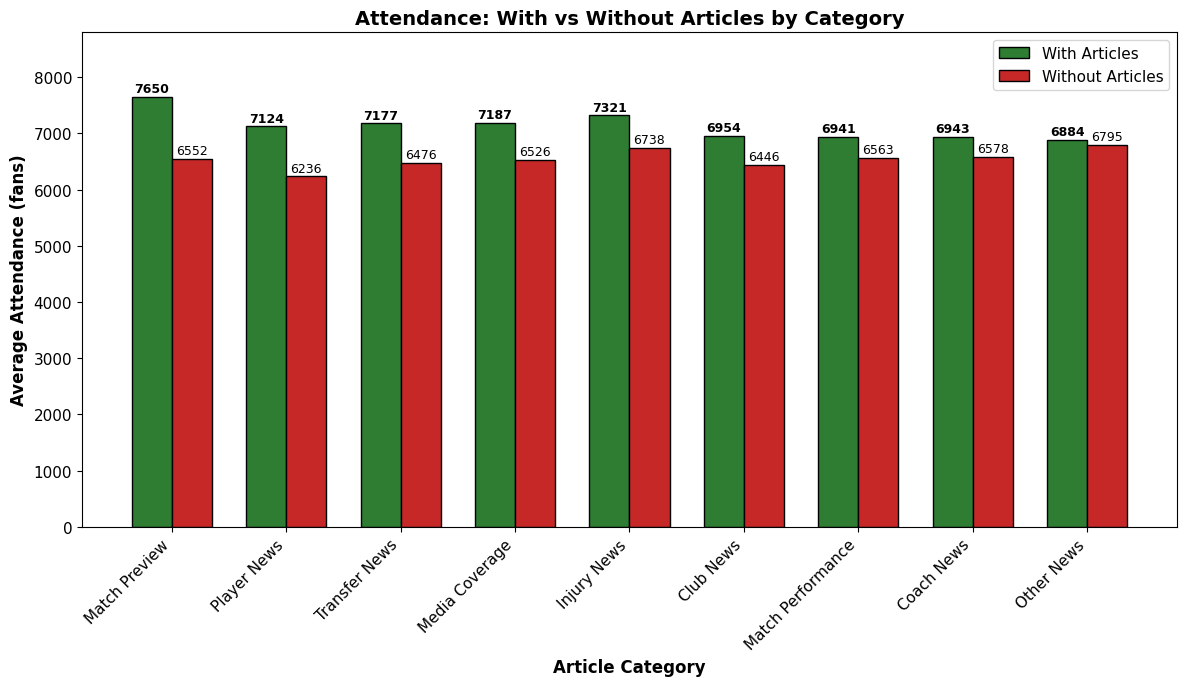


SUMMARY OF ARTICLE IMPACT

Overall average attendance: 6862 fans

Most Effective Article Categories:
  Match Preview: +1099 fans (+17%) when articles present
  Player News: +887 fans (+14%) when articles present
  Transfer News: +701 fans (+11%) when articles present
  Media Coverage: +662 fans (+10%) when articles present
  Injury News: +583 fans (+9%) when articles present


In [360]:
# BAR CHART 1: Article Impact by Category
print("\nBAR CHART 1: Article Impact by Category")

# Get category columns
category_cols = [c for c in df_with_articles.columns if c.startswith('art_') and c not in ['art_total', 'art_home_mention', 'art_opponent_only', 'art_both_teams']]
category_names = [c.replace('art_', '').replace('_', ' ') for c in category_cols]

if len(category_cols) > 0:
    category_impact = []
    
    for col, name in zip(category_cols, category_names):
        with_articles = df_with_articles[df_with_articles[col] > 0]['tickets_scanned']
        without_articles = df_with_articles[df_with_articles[col] == 0]['tickets_scanned']
        
        if len(with_articles) > 0:
            with_mean = with_articles.mean()
            without_mean = without_articles.mean()
            diff = with_mean - without_mean
            pct_change = (diff / without_mean) * 100 if without_mean > 0 else 0
            
            category_impact.append({
                'category': name,
                'with_avg': with_mean,
                'with_min': with_articles.min(),
                'with_max': with_articles.max(),
                'without_avg': without_mean,
                'diff': diff,
                'pct': pct_change,
                'count': len(with_articles)
            })
    
    # Sort by difference (impact) descending
    impact_df = pd.DataFrame(category_impact).sort_values('diff', ascending=False)
    
    print("\nATTENDANCE BY ARTICLE CATEGORY:")
    print("-" * 85)
    print(f"{'Category':<20} {'With Articles':<15} {'Without Articles':<15} {'Difference':<12} {'Matches':<8}")
    print("-" * 85)
    
    for _, row in impact_df.iterrows():
        print(f"{row['category']:<20} {row['with_avg']:.0f}{' ':<8} {row['without_avg']:.0f}{' ':<8} +{row['diff']:.0f} ({row['pct']:+.0f}%){' ':<4} {row['count']:<8}")
    
    # Create bar chart
    fig, ax = plt.subplots(figsize=(12, 7))
    
    x = np.arange(len(impact_df))
    width = 0.35
    
    with_vals = impact_df['with_avg'].values
    without_vals = impact_df['without_avg'].values
    
    bars_with = ax.bar(x - width/2, with_vals, width, label='With Articles', color='#2E7D32', edgecolor='black')
    bars_without = ax.bar(x + width/2, without_vals, width, label='Without Articles', color='#C62828', edgecolor='black')
    
    ax.set_ylabel('Average Attendance (fans)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Article Category', fontsize=12, fontweight='bold')
    ax.set_title('Attendance: With vs Without Articles by Category', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(impact_df['category'], rotation=45, ha='right')
    ax.legend()
    
    max_val = max(with_vals.max(), without_vals.max())
    ax.set_ylim(0, max_val * 1.15)
    
    # Add value labels
    for bar, val in zip(bars_with, with_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30, f'{int(val)}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    for bar, val in zip(bars_without, without_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30, f'{int(val)}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    save_chart('article_impact_by_category_original')
    plt.show()
    
    # Summary of findings
    print("\n" + "=" * 80)
    print("SUMMARY OF ARTICLE IMPACT")
    print("=" * 80)
    print(f"\nOverall average attendance: {overall_avg:.0f} fans")
    print("\nMost Effective Article Categories:")
    for _, row in impact_df.head(5).iterrows():
        print(f"  {row['category']}: +{row['diff']:.0f} fans (+{row['pct']:.0f}%) when articles present")
    
else:
    print("No article categories with data to display")


BAR CHART 2: Article Impact by Category (Excluding Season Openers & Season Break Articles)

ATTENDANCE BY ARTICLE CATEGORY (Filtered):
-------------------------------------------------------------------------------------
Category             With Articles   Without Articles Difference   Matches 
-------------------------------------------------------------------------------------
Match Preview        7887         6597         +1290 (+20%)     17      
Injury News          7863         6719         +1144 (+17%)     12      
Player News          7238         6237         +1001 (+16%)     46      
Transfer News        7333         6477         +856 (+13%)     35      
Media Coverage       7360         6526         +834 (+13%)     32      
Club News            7039         6447         +593 (+9%)     54      
Match Performance    7028         6564         +464 (+7%)     52      
Coach News           7033         6578         +454 (+7%)     51      
Other News           6972         6795  

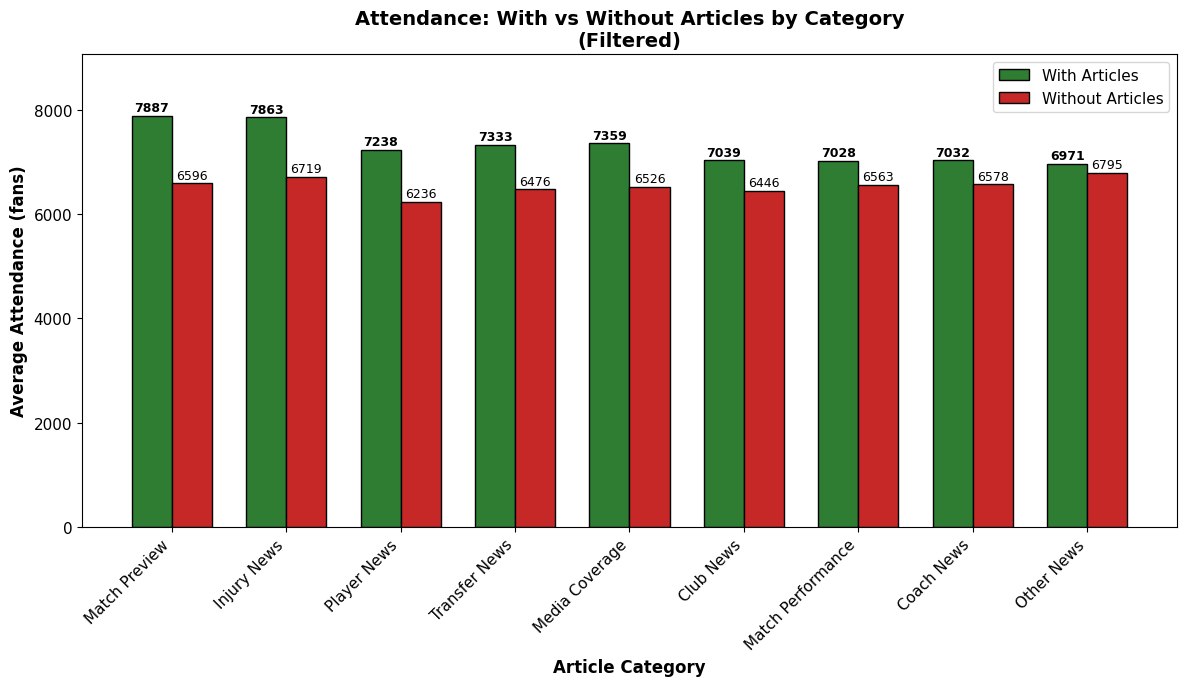


SUMMARY OF ARTICLE IMPACT (Filtered)

Overall average attendance: 6924 fans

Most Effective Article Categories:
  Match Preview: +1290 fans (+20%) when articles present
  Injury News: +1144 fans (+17%) when articles present
  Player News: +1001 fans (+16%) when articles present
  Transfer News: +856 fans (+13%) when articles present
  Media Coverage: +834 fans (+13%) when articles present


In [361]:
# BAR CHART 2: Article Impact by Category (Excluding Season Openers & Season Break Articles)
print("\nBAR CHART 2: Article Impact by Category (Excluding Season Openers & Season Break Articles)")

# Ensure season exists
if 'season' not in df_with_articles.columns:
    if 'season' in match_df.columns:
        df_with_articles = df_with_articles.merge(
            match_df[['match_id', 'season']],
            on='match_id',
            how='left'
        )
    else:
        df_with_articles['year'] = df_with_articles['match_date'].dt.year
        df_with_articles['season'] = (
            df_with_articles['year'].astype(str) + '/' +
            (df_with_articles['year'] + 1).astype(str)
        )

# Remove season openers
first_match_dates = df_with_articles.groupby('season')['match_date'].min()
df_filtered = df_with_articles[
    ~df_with_articles['match_date'].isin(first_match_dates.values)
].copy()

# Filter articles (remove pre-season articles)
if 'relevant_articles' in locals() and len(relevant_articles) > 0:
    
    season_starts = df_with_articles.groupby('season')['match_date'].min().to_dict()
    
    def is_article_during_season(article):
        match = df_with_articles[df_with_articles['match_id'] == article['match_id']]
        if len(match) == 0:
            return False
        
        season = match.iloc[0]['season']
        season_start = season_starts.get(season)
        
        if season_start is None:
            return True
        
        return article['article_date'] > season_start
    
    relevant_articles_filtered = relevant_articles[
        relevant_articles.apply(is_article_during_season, axis=1)
    ].copy()
    
else:
    relevant_articles_filtered = pd.DataFrame()

# Recalculate article counts
if len(relevant_articles_filtered) > 0 and len(df_filtered) > 0:
    
    match_article_counts = []
    
    categories = relevant_articles_filtered['category'].dropna().unique()
    
    for match_id in df_filtered['match_id'].unique():
        match_articles = relevant_articles_filtered[
            relevant_articles_filtered['match_id'] == match_id
        ]
        
        row_data = {'match_id': match_id}
        
        for category in categories:
            col_name = f'art_{category.replace(" ", "_")}'
            row_data[col_name] = (match_articles['category'] == category).sum()
        
        row_data['art_home_mention'] = (match_articles['has_home_mention'] == True).sum()
        row_data['art_opponent_only'] = (
            (match_articles['has_home_mention'] == False) &
            (match_articles['mentions_opponent'] == True)
        ).sum()
        row_data['art_both_teams'] = (
            (match_articles['has_home_mention'] == True) &
            (match_articles['mentions_opponent'] == True)
        ).sum()
        row_data['art_total'] = len(match_articles)
        
        match_article_counts.append(row_data)
    
    article_counts_filtered = pd.DataFrame(match_article_counts).fillna(0)
    
    # Ensure ints
    for col in article_counts_filtered.columns:
        if col != 'match_id':
            article_counts_filtered[col] = article_counts_filtered[col].astype(int)
    
    # remove old article columns before merge
    existing_art_cols = [c for c in df_filtered.columns if c.startswith('art_')]
    df_filtered = df_filtered.drop(columns=existing_art_cols, errors='ignore')
    
    df_filtered = df_filtered.merge(
        article_counts_filtered,
        on='match_id',
        how='left'
    )
    
    # Fill NaNs AFTER clean merge
    for col in article_counts_filtered.columns:
        if col != 'match_id':
            if col in df_filtered.columns:
                df_filtered[col] = df_filtered[col].fillna(0).astype(int)
    
    df_analysis = df_filtered
    overall_avg_filtered = df_analysis['tickets_scanned'].mean()

else:
    df_analysis = df_with_articles
    overall_avg_filtered = overall_avg

# ANALYSIS
category_cols = [
    c for c in df_analysis.columns
    if c.startswith('art_') and c not in [
        'art_total', 'art_home_mention', 'art_opponent_only', 'art_both_teams'
    ]
]

category_names = [c.replace('art_', '').replace('_', ' ') for c in category_cols]

if len(category_cols) > 0:
    category_impact = []
    
    for col, name in zip(category_cols, category_names):
        with_articles = df_analysis[df_analysis[col] > 0]['tickets_scanned']
        without_articles = df_analysis[df_analysis[col] == 0]['tickets_scanned']
        
        if len(with_articles) > 0:
            with_mean = with_articles.mean()
            without_mean = without_articles.mean()
            diff = with_mean - without_mean
            pct_change = (diff / without_mean) * 100 if without_mean > 0 else 0
            
            category_impact.append({
                'category': name,
                'with_avg': with_mean,
                'with_min': with_articles.min(),
                'with_max': with_articles.max(),
                'without_avg': without_mean,
                'diff': diff,
                'pct': pct_change,
                'count': len(with_articles)
            })
    
    impact_df = pd.DataFrame(category_impact).sort_values('diff', ascending=False)
    
    print("\nATTENDANCE BY ARTICLE CATEGORY (Filtered):")
    print("-" * 85)
    print(f"{'Category':<20} {'With Articles':<15} {'Without Articles':<15} {'Difference':<12} {'Matches':<8}")
    print("-" * 85)
    
    for _, row in impact_df.iterrows():
        print(f"{row['category']:<20} {row['with_avg']:.0f}{' ':<8} {row['without_avg']:.0f}{' ':<8} +{row['diff']:.0f} ({row['pct']:+.0f}%){' ':<4} {row['count']:<8}")
    
    # ---- BAR CHART ----
    fig, ax = plt.subplots(figsize=(12, 7))
    
    x = np.arange(len(impact_df))
    width = 0.35
    
    with_vals = impact_df['with_avg'].values
    without_vals = impact_df['without_avg'].values
    
    bars_with = ax.bar(x - width/2, with_vals, width, label='With Articles', color='#2E7D32', edgecolor='black')
    bars_without = ax.bar(x + width/2, without_vals, width, label='Without Articles', color='#C62828', edgecolor='black')
    
    ax.set_ylabel('Average Attendance (fans)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Article Category', fontsize=12, fontweight='bold')
    ax.set_title('Attendance: With vs Without Articles by Category\n(Filtered)', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(impact_df['category'], rotation=45, ha='right')
    ax.legend()
    
    max_val = max(with_vals.max(), without_vals.max())
    ax.set_ylim(0, max_val * 1.15)
    
    for bar, val in zip(bars_with, with_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                f'{int(val)}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    for bar, val in zip(bars_without, without_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                f'{int(val)}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    save_chart('article_impact_excluding_openers')
    plt.show()
    
    # SUMMARY
    print("\n" + "=" * 80)
    print("SUMMARY OF ARTICLE IMPACT (Filtered)")
    print("=" * 80)
    print(f"\nOverall average attendance: {overall_avg_filtered:.0f} fans")
    
    print("\nMost Effective Article Categories:")
    for _, row in impact_df.head(5).iterrows():
        print(f"  {row['category']}: +{row['diff']:.0f} fans (+{row['pct']:.0f}%) when articles present")

else:
    print("No article categories with data to display")


BAR CHART 3: Tickets Sold vs Tickets Scanned by Article Category (Including Season Pass Holders)
Merged ticket data

TICKETS SOLD VS SCANNED BY ARTICLE CATEGORY (INCLUDING SEASON PASS):
-----------------------------------------------------------------------------------------------
Category             With Articles        Without Articles     No-Show Rate   
                     Total    Scanned  Total    Scanned  With     Without 
-----------------------------------------------------------------------------------------------
Match Preview        11395     7887     10846     6597     31%     40%
Injury News          11668     7863     10836     6719     33%     38%
Media Coverage       10845     7360     11114     6526     33%     41%
Transfer News        10905     7333     11072     6477     34%     42%
Player News          11096     7238     10742     6237     35%     42%
Club News            10950     7039     11131     6447     36%     42%
Coach News           10983     7033     1

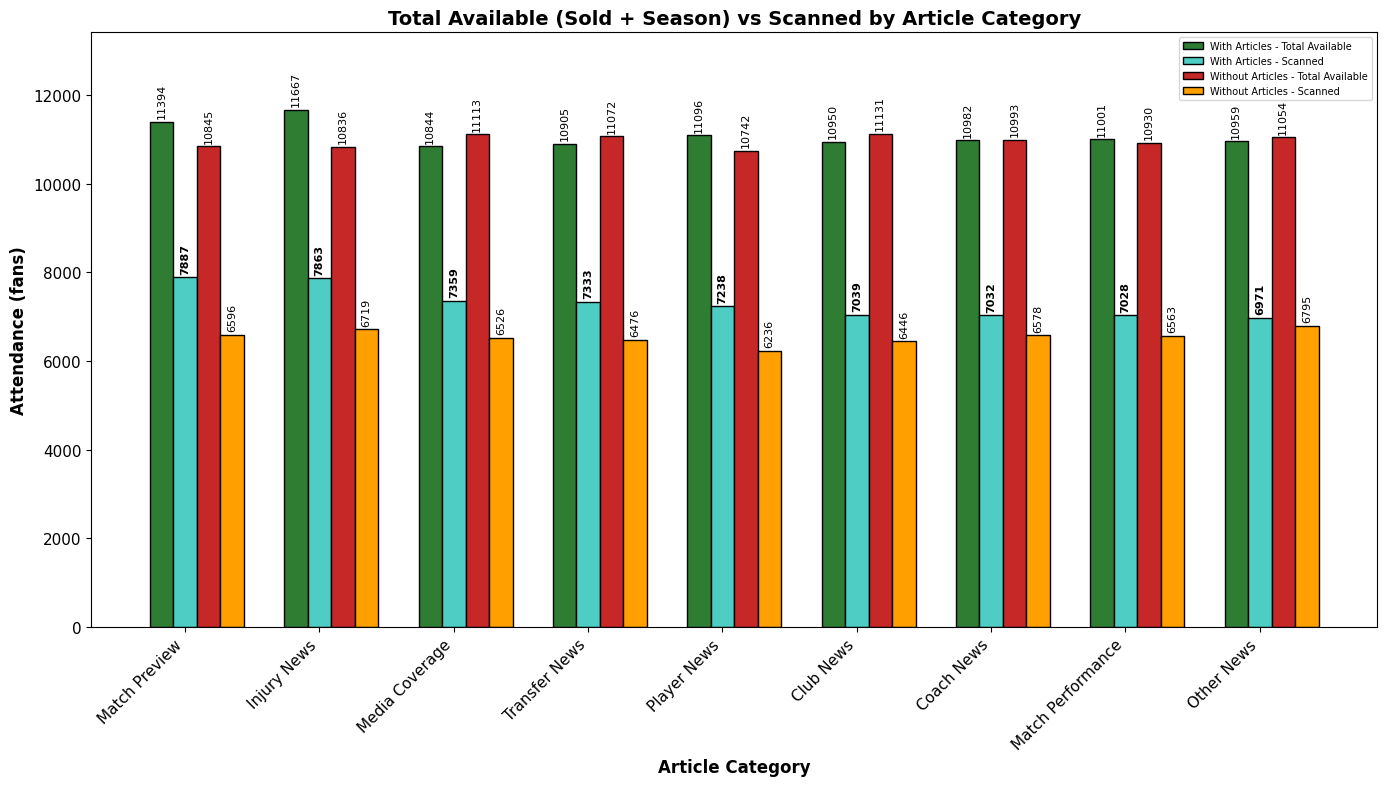


NO-SHOW RATE ANALYSIS

Overall average no-show rate: 37.5%

No-Show Rate by Article Category:
  Match Preview:
    With articles: 30.8% no-show
    Without articles: 39.7% no-show
    → Articles reduce no-shows by 8.9%
  Injury News:
    With articles: 33.0% no-show
    Without articles: 38.4% no-show
    → Articles reduce no-shows by 5.4%
  Media Coverage:
    With articles: 33.1% no-show
    Without articles: 41.4% no-show
    → Articles reduce no-shows by 8.3%
  Transfer News:
    With articles: 33.6% no-show
    Without articles: 41.7% no-show
    → Articles reduce no-shows by 8.1%
  Player News:
    With articles: 35.4% no-show
    Without articles: 41.9% no-show
    → Articles reduce no-shows by 6.4%
  Club News:
    With articles: 36.3% no-show
    Without articles: 42.1% no-show
    → Articles reduce no-shows by 5.8%
  Coach News:
    With articles: 36.5% no-show
    Without articles: 40.5% no-show
    → Articles reduce no-shows by 4.1%
  Match Performance:
    With articles: 

In [362]:
# BAR CHART 3: Tickets Sold vs Tickets Scanned by Article Category (Including Season Pass Holders)
print("\nBAR CHART 3: Tickets Sold vs Tickets Scanned by Article Category (Including Season Pass Holders)")

# ---------------------------
# STEP 1: Remove season openers & break articles
# ---------------------------
first_match_dates = df_with_articles.groupby('season')['match_date'].min()
df_filtered = df_with_articles[
    ~df_with_articles['match_date'].isin(first_match_dates.values)
].copy()

if 'relevant_articles' in locals() and len(relevant_articles) > 0:
    season_starts = df_with_articles.groupby('season')['match_date'].min().to_dict()
    
    def is_article_during_season(article):
        match = df_with_articles[df_with_articles['match_id'] == article['match_id']]
        if len(match) == 0:
            return False
        season = match.iloc[0]['season']
        season_start = season_starts.get(season)
        if season_start is None:
            return True
        return article['article_date'] > season_start
    
    relevant_articles_filtered = relevant_articles[
        relevant_articles.apply(is_article_during_season, axis=1)
    ].copy()
else:
    relevant_articles_filtered = pd.DataFrame()

# Recalculate article counts for filtered data
if len(relevant_articles_filtered) > 0 and len(df_filtered) > 0:
    match_article_counts = []
    categories = relevant_articles_filtered['category'].dropna().unique()
    
    for match_id in df_filtered['match_id'].unique():
        match_articles = relevant_articles_filtered[relevant_articles_filtered['match_id'] == match_id]
        row_data = {'match_id': match_id}
        for category in categories:
            col_name = f'art_{category.replace(" ", "_")}'
            row_data[col_name] = (match_articles['category'] == category).sum()
        row_data['art_home_mention'] = (match_articles['has_home_mention'] == True).sum()
        row_data['art_opponent_only'] = ((match_articles['has_home_mention'] == False) & 
                                         (match_articles['mentions_opponent'] == True)).sum()
        row_data['art_both_teams'] = ((match_articles['has_home_mention'] == True) & 
                                      (match_articles['mentions_opponent'] == True)).sum()
        row_data['art_total'] = len(match_articles)
        match_article_counts.append(row_data)
    
    article_counts_filtered = pd.DataFrame(match_article_counts).fillna(0)
    for col in article_counts_filtered.columns:
        if col != 'match_id':
            article_counts_filtered[col] = article_counts_filtered[col].astype(int)
    
    existing_art_cols = [c for c in df_filtered.columns if c.startswith('art_')]
    df_filtered = df_filtered.drop(columns=existing_art_cols, errors='ignore')
    df_filtered = df_filtered.merge(article_counts_filtered, on='match_id', how='left')
    
    for col in article_counts_filtered.columns:
        if col != 'match_id' and col in df_filtered.columns:
            df_filtered[col] = df_filtered[col].fillna(0).astype(int)
    
    df_analysis = df_filtered
else:
    df_analysis = df_with_articles

# ---------------------------
# STEP 2: Ensure ticket columns exist
# ---------------------------
if 'tickets_sold_total' not in df_analysis.columns or 'seasonpass_holders' not in df_analysis.columns:
    try:
        tickets_df = pd.read_csv('data/gold_match_tickets.csv', on_bad_lines='skip')
        tickets_df.columns = tickets_df.columns.str.strip()
        df_analysis = df_analysis.merge(
            tickets_df[['match_id', 'tickets_sold_total', 'seasonpass_holders']], 
            on='match_id', how='left'
        )
        print("Merged ticket data")
    except Exception as e:
        print(f"Error loading tickets data: {e}")

df_analysis['tickets_sold_total'] = df_analysis['tickets_sold_total'].fillna(0)
df_analysis['seasonpass_holders'] = df_analysis['seasonpass_holders'].fillna(0)
df_analysis['total_tickets_available'] = df_analysis['tickets_sold_total'] + df_analysis['seasonpass_holders']
df_analysis['no_show_rate'] = 0
mask = df_analysis['total_tickets_available'] > 0
df_analysis.loc[mask, 'no_show_rate'] = (
    df_analysis.loc[mask, 'total_tickets_available'] - df_analysis.loc[mask, 'tickets_scanned']
) / df_analysis.loc[mask, 'total_tickets_available']

# ---------------------------
# STEP 3: Analysis by article category
# ---------------------------
category_cols = [c for c in df_analysis.columns if c.startswith('art_') and c not in ['art_total', 'art_home_mention', 'art_opponent_only', 'art_both_teams']]
category_names = [c.replace('art_', '').replace('_', ' ') for c in category_cols]

if len(category_cols) > 0:
    ticket_impact = []
    for col, name in zip(category_cols, category_names):
        with_articles = df_analysis[df_analysis[col] > 0]
        without_articles = df_analysis[df_analysis[col] == 0]
        if len(with_articles) > 0:
            ticket_impact.append({
                'category': name,
                'with_count': len(with_articles),
                'without_count': len(without_articles),
                'with_total': with_articles['total_tickets_available'].mean(),
                'with_scanned': with_articles['tickets_scanned'].mean(),
                'with_no_show': with_articles['no_show_rate'].mean() * 100,
                'without_total': without_articles['total_tickets_available'].mean(),
                'without_scanned': without_articles['tickets_scanned'].mean(),
                'without_no_show': without_articles['no_show_rate'].mean() * 100
            })
    
    ticket_df = pd.DataFrame(ticket_impact).sort_values('with_scanned', ascending=False)

    # ---------------------------
    # STEP 4: Print table and plot
    # ---------------------------
    print("\nTICKETS SOLD VS SCANNED BY ARTICLE CATEGORY (INCLUDING SEASON PASS):")
    print("-" * 95)
    print(f"{'Category':<20} {'With Articles':<20} {'Without Articles':<20} {'No-Show Rate':<15}")
    print(f"{'':<20} {'Total':<8} {'Scanned':<8} {'Total':<8} {'Scanned':<8} {'With':<8} {'Without':<8}")
    print("-" * 95)
    for _, row in ticket_df.iterrows():
        print(f"{row['category']:<20} {row['with_total']:.0f}{' ':<4} {row['with_scanned']:.0f}{' ':<4} {row['without_total']:.0f}{' ':<4} {row['without_scanned']:.0f}{' ':<4} {row['with_no_show']:.0f}%{' ':<4} {row['without_no_show']:.0f}%")
    
    # Plotting
    fig, ax = plt.subplots(figsize=(14, 8))
    x = np.arange(len(ticket_df))
    width = 0.35

    bars_with_total = ax.bar(x - width/2, ticket_df['with_total'].values, width/2, label='With Articles - Total Available', color='#2E7D32', edgecolor='black')
    bars_with_scanned = ax.bar(x, ticket_df['with_scanned'].values, width/2, label='With Articles - Scanned', color='#4ECDC4', edgecolor='black')
    bars_without_total = ax.bar(x + width/2, ticket_df['without_total'].values, width/2, label='Without Articles - Total Available', color='#C62828', edgecolor='black')
    bars_without_scanned = ax.bar(x + width, ticket_df['without_scanned'].values, width/2, label='Without Articles - Scanned', color='#FFA000', edgecolor='black')

    ax.set_ylabel('Attendance (fans)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Article Category', fontsize=12, fontweight='bold')
    ax.set_title('Total Available (Sold + Season) vs Scanned by Article Category', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(ticket_df['category'], rotation=45, ha='right')
    ax.legend(loc='upper right', fontsize=7)

    max_val = max(ticket_df['with_total'].max(), ticket_df['with_scanned'].max(), ticket_df['without_total'].max(), ticket_df['without_scanned'].max())
    ax.set_ylim(0, max_val * 1.15)

    for bar, val in zip(bars_with_total, ticket_df['with_total'].values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80, f'{int(val)}', ha='center', va='bottom', fontsize=8, rotation=90)
    for bar, val in zip(bars_with_scanned, ticket_df['with_scanned'].values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80, f'{int(val)}', ha='center', va='bottom', fontsize=8, rotation=90, fontweight='bold')
    for bar, val in zip(bars_without_total, ticket_df['without_total'].values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80, f'{int(val)}', ha='center', va='bottom', fontsize=8, rotation=90)
    for bar, val in zip(bars_without_scanned, ticket_df['without_scanned'].values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80, f'{int(val)}', ha='center', va='bottom', fontsize=8, rotation=90)

    plt.tight_layout()
    save_chart('article_impact_tickets_sold_vs_scanned_with_season')
    plt.show()

    print("\n" + "=" * 80)
    print("NO-SHOW RATE ANALYSIS")
    print("=" * 80)
    print(f"\nOverall average no-show rate: {df_analysis['no_show_rate'].mean()*100:.1f}%")
    print("\nNo-Show Rate by Article Category:")
    for _, row in ticket_df.iterrows():
        diff_no_show = row['with_no_show'] - row['without_no_show']
        print(f"  {row['category']}:")
        print(f"    With articles: {row['with_no_show']:.1f}% no-show")
        print(f"    Without articles: {row['without_no_show']:.1f}% no-show")
        if diff_no_show < 0:
            print(f"    → Articles reduce no-shows by {abs(diff_no_show):.1f}%")
        elif diff_no_show > 0:
            print(f"    → Articles increase no-shows by {diff_no_show:.1f}%")

else:
    print("No article categories with data to display")


BAR CHART 4: Tickets Sold vs Tickets Scanned by Article Category
Merged tickets_sold_total data

TICKETS SOLD VS SCANNED BY ARTICLE CATEGORY (Filtered):
-----------------------------------------------------------------------------------------------
Category             With Articles        Without Articles     No-Show Rate   
                     Sold     Scanned  Sold     Scanned  With     Without 
-----------------------------------------------------------------------------------------------
Match Preview        7071     7887     6608     6597     -12%     2%
Injury News          7266     7863     6608     6719     -8%     -0%
Media Coverage       6688     7360     6760     6526     -7%     3%
Transfer News        6738     7333     6712     6477     -6%     3%
Player News          6861     7238     6429     6237     -3%     2%
Club News            6711     7039     6784     6447     -3%     5%
Coach News           6752     7033     6640     6578     -3%     1%
Match Performance    6

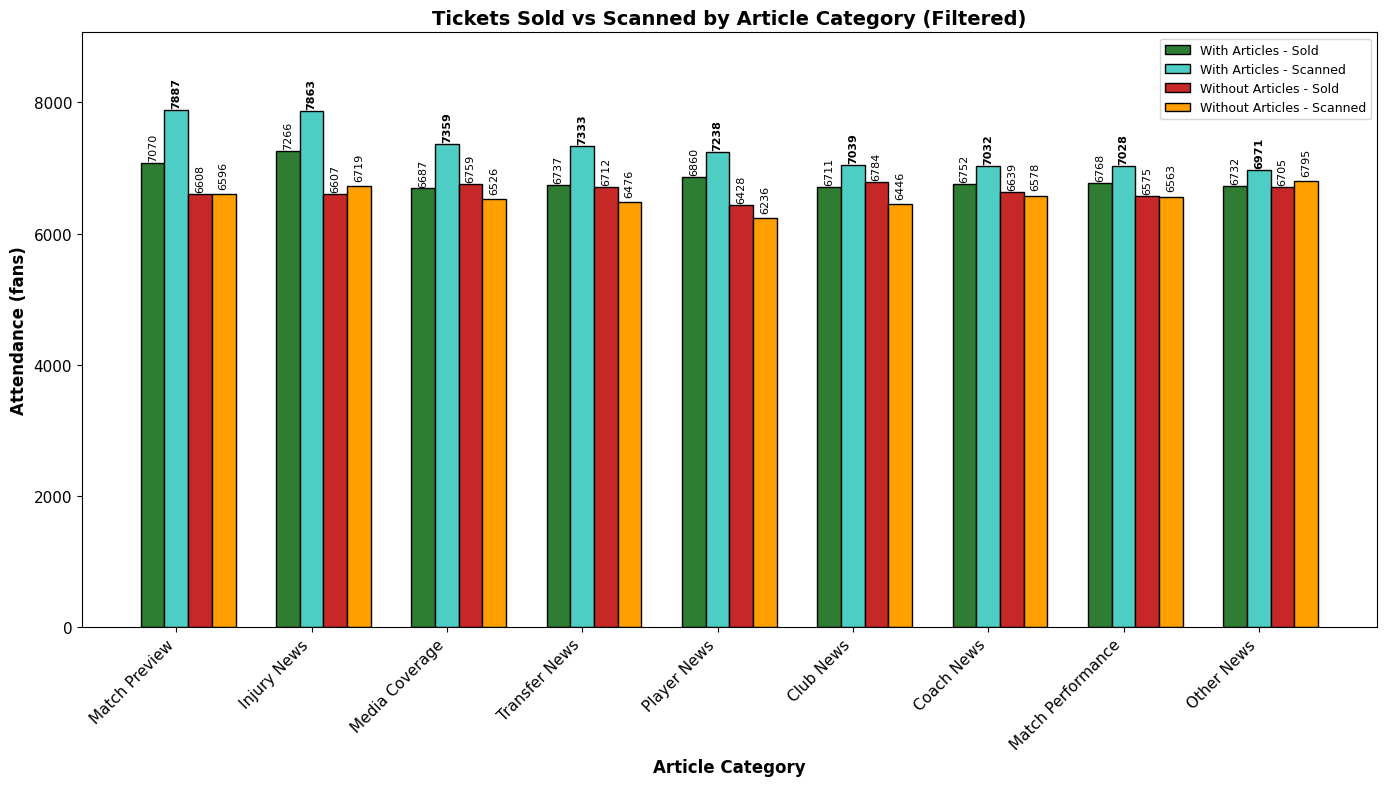


NO-SHOW RATE ANALYSIS (Filtered)

Overall average no-show rate: -1.7%

No-Show Rate by Article Category:
  Match Preview:
    With articles: -11.7% no-show rate
    Without articles: 1.7% no-show rate
    Difference: -13.4%
  Injury News:
    With articles: -7.8% no-show rate
    Without articles: -0.4% no-show rate
    Difference: -7.4%
  Media Coverage:
    With articles: -7.2% no-show rate
    Without articles: 3.3% no-show rate
    Difference: -10.6%
  Transfer News:
    With articles: -6.1% no-show rate
    Without articles: 3.1% no-show rate
    Difference: -9.1%
  Player News:
    With articles: -3.5% no-show rate
    Without articles: 2.1% no-show rate
    Difference: -5.6%
  Club News:
    With articles: -3.3% no-show rate
    Without articles: 4.6% no-show rate
    Difference: -7.9%
  Coach News:
    With articles: -2.7% no-show rate
    Without articles: 1.3% no-show rate
    Difference: -4.0%
  Match Performance:
    With articles: -2.5% no-show rate
    Without articles: 

In [363]:
# BAR CHART 4: Tickets Sold vs Tickets Scanned by Article Category
print("\nBAR CHART 4: Tickets Sold vs Tickets Scanned by Article Category")

# ---------------------------
# STEP 1: Filter matches and articles
# ---------------------------
# Remove season openers
first_match_dates = df_with_articles.groupby('season')['match_date'].min()
df_filtered = df_with_articles[~df_with_articles['match_date'].isin(first_match_dates.values)].copy()

# Filter relevant articles
if 'relevant_articles' in locals() and len(relevant_articles) > 0:
    season_starts = df_with_articles.groupby('season')['match_date'].min().to_dict()
    
    def is_article_during_season(article):
        match = df_with_articles[df_with_articles['match_id'] == article['match_id']]
        if len(match) == 0:
            return False
        season = match.iloc[0]['season']
        season_start = season_starts.get(season)
        if season_start is None:
            return True
        return article['article_date'] > season_start
    
    relevant_articles_filtered = relevant_articles[
        relevant_articles.apply(is_article_during_season, axis=1)
    ].copy()
else:
    relevant_articles_filtered = pd.DataFrame()

# ---------------------------
# STEP 2: Merge article counts with filtered matches
# ---------------------------
if len(relevant_articles_filtered) > 0 and len(df_filtered) > 0:
    match_article_counts = []
    categories = relevant_articles_filtered['category'].dropna().unique()
    
    for match_id in df_filtered['match_id'].unique():
        match_articles = relevant_articles_filtered[relevant_articles_filtered['match_id'] == match_id]
        row_data = {'match_id': match_id}
        for category in categories:
            col_name = f'art_{category.replace(" ", "_")}'
            row_data[col_name] = (match_articles['category'] == category).sum()
        row_data['art_home_mention'] = (match_articles['has_home_mention'] == True).sum()
        row_data['art_opponent_only'] = ((match_articles['has_home_mention'] == False) & (match_articles['mentions_opponent'] == True)).sum()
        row_data['art_both_teams'] = ((match_articles['has_home_mention'] == True) & (match_articles['mentions_opponent'] == True)).sum()
        row_data['art_total'] = len(match_articles)
        match_article_counts.append(row_data)
    
    article_counts_filtered = pd.DataFrame(match_article_counts).fillna(0)
    for col in article_counts_filtered.columns:
        if col != 'match_id':
            article_counts_filtered[col] = article_counts_filtered[col].astype(int)
    
    # Remove old article columns to avoid duplicates
    existing_art_cols = [c for c in df_filtered.columns if c.startswith('art_')]
    df_filtered = df_filtered.drop(columns=existing_art_cols, errors='ignore')
    
    df_filtered = df_filtered.merge(article_counts_filtered, on='match_id', how='left')
    for col in article_counts_filtered.columns:
        if col != 'match_id' and col in df_filtered.columns:
            df_filtered[col] = df_filtered[col].fillna(0).astype(int)
    
    df_analysis = df_filtered
else:
    df_analysis = df_with_articles

# ---------------------------
# STEP 3: Ensure tickets_sold_total exists
# ---------------------------
if 'tickets_sold_total' not in df_analysis.columns:
    try:
        tickets_df = pd.read_csv('data/gold_match_tickets.csv', on_bad_lines='skip')
        tickets_df.columns = tickets_df.columns.str.strip()
        df_analysis = df_analysis.merge(tickets_df[['match_id', 'tickets_sold_total', 'seasonpass_holders']], 
                                        on='match_id', how='left')
        print("Merged tickets_sold_total data")
    except Exception as e:
        print(f"Error loading tickets data: {e}")
        df_analysis['tickets_sold_total'] = 0

df_analysis['tickets_sold_total'] = df_analysis['tickets_sold_total'].fillna(0)
df_analysis['no_show_rate'] = 0
mask = df_analysis['tickets_sold_total'] > 0
df_analysis.loc[mask, 'no_show_rate'] = (df_analysis.loc[mask, 'tickets_sold_total'] - 
                                         df_analysis.loc[mask, 'tickets_scanned']) / df_analysis.loc[mask, 'tickets_sold_total']

# ---------------------------
# STEP 4: Calculate ticket metrics by category
# ---------------------------
category_cols = [c for c in df_analysis.columns if c.startswith('art_') and c not in ['art_total', 'art_home_mention', 'art_opponent_only', 'art_both_teams']]
category_names = [c.replace('art_', '').replace('_', ' ') for c in category_cols]

if len(category_cols) > 0:
    ticket_impact = []
    
    for col, name in zip(category_cols, category_names):
        with_articles = df_analysis[df_analysis[col] > 0]
        without_articles = df_analysis[df_analysis[col] == 0]
        
        if len(with_articles) > 0:
            ticket_impact.append({
                'category': name,
                'with_count': len(with_articles),
                'without_count': len(without_articles),
                'with_sold': with_articles['tickets_sold_total'].mean(),
                'with_scanned': with_articles['tickets_scanned'].mean(),
                'with_no_show': with_articles['no_show_rate'].mean() * 100,
                'without_sold': without_articles['tickets_sold_total'].mean(),
                'without_scanned': without_articles['tickets_scanned'].mean(),
                'without_no_show': without_articles['no_show_rate'].mean() * 100
            })
    
    ticket_df = pd.DataFrame(ticket_impact).sort_values('with_scanned', ascending=False)

    # ---------------------------
    # STEP 5: Print table & plot
    # ---------------------------
    print("\nTICKETS SOLD VS SCANNED BY ARTICLE CATEGORY (Filtered):")
    print("-" * 95)
    print(f"{'Category':<20} {'With Articles':<20} {'Without Articles':<20} {'No-Show Rate':<15}")
    print(f"{'':<20} {'Sold':<8} {'Scanned':<8} {'Sold':<8} {'Scanned':<8} {'With':<8} {'Without':<8}")
    print("-" * 95)
    
    for _, row in ticket_df.iterrows():
        print(f"{row['category']:<20} {row['with_sold']:.0f}{' ':<4} {row['with_scanned']:.0f}{' ':<4} {row['without_sold']:.0f}{' ':<4} {row['without_scanned']:.0f}{' ':<4} {row['with_no_show']:.0f}%{' ':<4} {row['without_no_show']:.0f}%")
    
    fig, ax = plt.subplots(figsize=(14, 8))
    x = np.arange(len(ticket_df))
    width = 0.35
    
    bars_with_sold = ax.bar(x - width/2, ticket_df['with_sold'].values, width/2, label='With Articles - Sold', color='#2E7D32', edgecolor='black')
    bars_with_scanned = ax.bar(x, ticket_df['with_scanned'].values, width/2, label='With Articles - Scanned', color='#4ECDC4', edgecolor='black')
    bars_without_sold = ax.bar(x + width/2, ticket_df['without_sold'].values, width/2, label='Without Articles - Sold', color='#C62828', edgecolor='black')
    bars_without_scanned = ax.bar(x + width, ticket_df['without_scanned'].values, width/2, label='Without Articles - Scanned', color='#FFA000', edgecolor='black')
    
    ax.set_ylabel('Attendance (fans)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Article Category', fontsize=12, fontweight='bold')
    ax.set_title('Tickets Sold vs Scanned by Article Category (Filtered)', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(ticket_df['category'], rotation=45, ha='right')
    ax.legend(loc='upper right', fontsize=9)
    
    max_val = max(ticket_df['with_sold'].max(), ticket_df['with_scanned'].max(),
                  ticket_df['without_sold'].max(), ticket_df['without_scanned'].max())
    ax.set_ylim(0, max_val * 1.15)
    
    for bar, val in zip(bars_with_sold, ticket_df['with_sold'].values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30, f'{int(val)}', ha='center', va='bottom', fontsize=8, rotation=90)
    for bar, val in zip(bars_with_scanned, ticket_df['with_scanned'].values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30, f'{int(val)}', ha='center', va='bottom', fontsize=8, rotation=90, fontweight='bold')
    for bar, val in zip(bars_without_sold, ticket_df['without_sold'].values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30, f'{int(val)}', ha='center', va='bottom', fontsize=8, rotation=90)
    for bar, val in zip(bars_without_scanned, ticket_df['without_scanned'].values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80, f'{int(val)}', ha='center', va='bottom', fontsize=8, rotation=90)
    
    plt.tight_layout()
    save_chart('article_impact_tickets_sold_vs_scanned_without_season')
    plt.show()
    
    print("\n" + "=" * 80)
    print("NO-SHOW RATE ANALYSIS (Filtered)")
    print("=" * 80)
    print(f"\nOverall average no-show rate: {df_analysis['no_show_rate'].mean()*100:.1f}%")
    print("\nNo-Show Rate by Article Category:")
    for _, row in ticket_df.iterrows():
        diff_no_show = row['with_no_show'] - row['without_no_show']
        print(f"  {row['category']}:")
        print(f"    With articles: {row['with_no_show']:.1f}% no-show rate")
        print(f"    Without articles: {row['without_no_show']:.1f}% no-show rate")
        print(f"    Difference: {diff_no_show:+.1f}%")
else:
    print("No article categories with data to display")


BAR CHART 5: Team Mention Impact

ATTENDANCE BY TEAM MENTION TYPE:
-------------------------------------------------------------------------------------
Mention Type       Average      Min          Max          Matches 
-------------------------------------------------------------------------------------
Home Team Only     5965 fans      3537      10723      24      
Both Teams         6821 fans      3537      11069      64      
No Articles        7235 fans      4913      10079      7       
✓ Chart saved: bar_charts/team_mention_impact.png


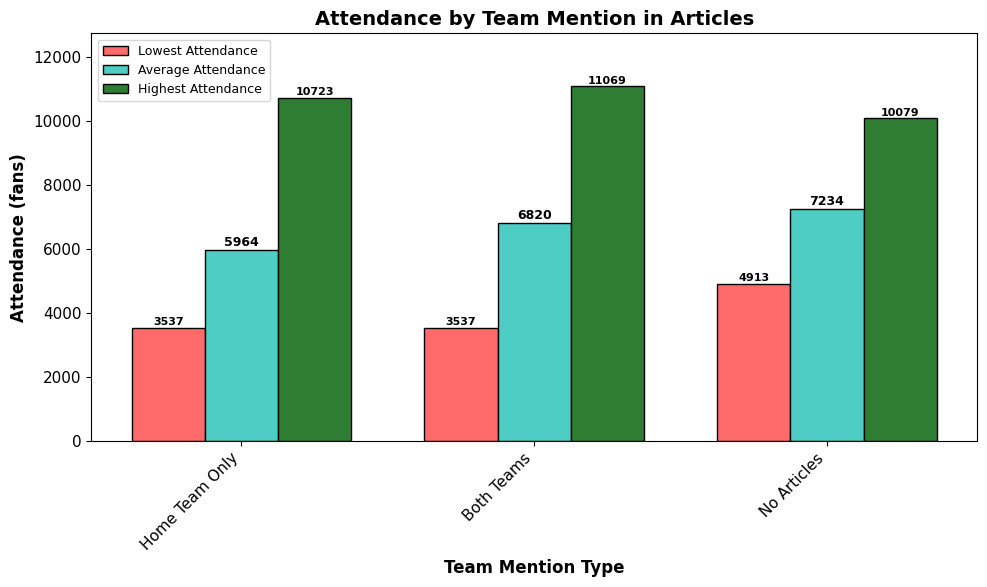

In [364]:
# BAR CHART 5: Team Mention Impact
print("\nBAR CHART 5: Team Mention Impact")

if len(df_with_articles) > 0:
    # Calculate impact by mention type
    mention_impact = []
    
    # Home team mention only
    home_mask = (df_with_articles['art_home_mention'] > 0) & (df_with_articles['art_opponent_only'] == 0)
    if home_mask.sum() > 0:
        mention_impact.append({
            'mention_type': 'Home Team Only',
            'avg': df_with_articles[home_mask]['tickets_scanned'].mean(),
            'min': df_with_articles[home_mask]['tickets_scanned'].min(),
            'max': df_with_articles[home_mask]['tickets_scanned'].max(),
            'count': home_mask.sum()
        })
    
    # Opponent only
    opp_mask = (df_with_articles['art_opponent_only'] > 0) & (df_with_articles['art_home_mention'] == 0)
    if opp_mask.sum() > 0:
        mention_impact.append({
            'mention_type': 'Opponent Only',
            'avg': df_with_articles[opp_mask]['tickets_scanned'].mean(),
            'min': df_with_articles[opp_mask]['tickets_scanned'].min(),
            'max': df_with_articles[opp_mask]['tickets_scanned'].max(),
            'count': opp_mask.sum()
        })
    
    # Both teams
    both_mask = df_with_articles['art_both_teams'] > 0
    if both_mask.sum() > 0:
        mention_impact.append({
            'mention_type': 'Both Teams',
            'avg': df_with_articles[both_mask]['tickets_scanned'].mean(),
            'min': df_with_articles[both_mask]['tickets_scanned'].min(),
            'max': df_with_articles[both_mask]['tickets_scanned'].max(),
            'count': both_mask.sum()
        })
    
    # No mention
    no_mask = df_with_articles['art_total'] == 0
    if no_mask.sum() > 0:
        mention_impact.append({
            'mention_type': 'No Articles',
            'avg': df_with_articles[no_mask]['tickets_scanned'].mean(),
            'min': df_with_articles[no_mask]['tickets_scanned'].min(),
            'max': df_with_articles[no_mask]['tickets_scanned'].max(),
            'count': no_mask.sum()
        })
    
    if len(mention_impact) > 0:
        mention_df = pd.DataFrame(mention_impact)
        
        print("\nATTENDANCE BY TEAM MENTION TYPE:")
        print("-" * 85)
        print(f"{'Mention Type':<18} {'Average':<12} {'Min':<12} {'Max':<12} {'Matches':<8}")
        print("-" * 85)
        
        for _, row in mention_df.iterrows():
            print(f"{row['mention_type']:<18} {row['avg']:.0f} fans      {row['min']:.0f}      {row['max']:.0f}      {row['count']:<8}")
        
        # Create bar chart
        fig, ax = plt.subplots(figsize=(10, 6))
        
        x = np.arange(len(mention_df))
        width = 0.25
        
        min_vals = mention_df['min'].values
        avg_vals = mention_df['avg'].values
        max_vals = mention_df['max'].values
        
        bars_min = ax.bar(x - width, min_vals, width, label='Lowest Attendance', color='#FF6B6B', edgecolor='black')
        bars_avg = ax.bar(x, avg_vals, width, label='Average Attendance', color='#4ECDC4', edgecolor='black')
        bars_max = ax.bar(x + width, max_vals, width, label='Highest Attendance', color='#2E7D32', edgecolor='black')
        
        ax.set_ylabel('Attendance (fans)', fontsize=12, fontweight='bold')
        ax.set_xlabel('Team Mention Type', fontsize=12, fontweight='bold')
        ax.set_title('Attendance by Team Mention in Articles', fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(mention_df['mention_type'], rotation=45, ha='right')
        ax.legend(loc='upper left', fontsize=9)
        
        max_val = max(max_vals)
        ax.set_ylim(0, max_val * 1.15)
        
        # Add average value labels on bars
        for bar, val in zip(bars_avg, avg_vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30, 
                    f'{int(val)}', ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        # Add min and max value labels on bars
        for i, (bar_min, bar_max) in enumerate(zip(bars_min, bars_max)):
            if min_vals[i] > 0:
                ax.text(bar_min.get_x() + bar_min.get_width()/2, bar_min.get_height() + 15, 
                        f'{int(min_vals[i])}', ha='center', va='bottom', fontsize=8, fontweight='bold')
            if max_vals[i] > 0:
                ax.text(bar_max.get_x() + bar_max.get_width()/2, bar_max.get_height() + 15, 
                        f'{int(max_vals[i])}', ha='center', va='bottom', fontsize=8, fontweight='bold')
        
        plt.tight_layout()
        save_chart('team_mention_impact')
        plt.show()
    else:
        print("No mention type data to display")
else:
    print("No data available for analysis")

In [365]:
# SUMMARY - CLUB NEWS & MEDIA ATTENTION
print("\nSUMMARY - CLUB NEWS & MEDIA ATTENTION")
print("-" * 60)

if len(relevant_articles) > 0:
    print("\nKEY FINDINGS:")
    print(f"\n1. ARTICLES THAT MENTION THE OPPONENT:")
    print(f"   Total articles mentioning opponent: {len(relevant_articles)}")
    if len(df_with_articles) > 0:
        print(f"   Matches with opponent-related articles: {len(df_with_articles[df_with_articles['art_total'] > 0])}")
    
    if len(category_cols) > 0 and 'impact_df' in locals() and len(impact_df) > 0:
        print("\n2. BEST ARTICLE CATEGORIES:")
        for _, row in impact_df.head(3).iterrows():
            diff = row['with_avg'] - row['without_avg']
            print(f"   {row['category']}: +{diff:.0f} fans when articles present")
    
    if len(mention_impact) > 0:
        print("\n3. TEAM MENTION IMPACT:")
        for _, row in mention_df.iterrows():
            diff = row['avg'] - overall_avg
            print(f"   {row['mention_type']}: {row['avg']:.0f} fans ({diff:+.0f} fans)")
else:
    print("\nNo articles found that mention upcoming opponents")
    print("Consider publishing more opponent-focused content before matches")



SUMMARY - CLUB NEWS & MEDIA ATTENTION
------------------------------------------------------------

KEY FINDINGS:

1. ARTICLES THAT MENTION THE OPPONENT:
   Total articles mentioning opponent: 3810
   Matches with opponent-related articles: 64

2. BEST ARTICLE CATEGORIES:
   Match Preview: +1290 fans when articles present
   Injury News: +1144 fans when articles present
   Player News: +1001 fans when articles present

3. TEAM MENTION IMPACT:
   Home Team Only: 5965 fans (-897 fans)
   Both Teams: 6821 fans (-41 fans)
   No Articles: 7235 fans (+373 fans)



2. ATTENDANCE BY OPPONENT - ALL TEAMS

EXACT ATTENDANCE NUMBERS BY OPPONENT (ALL TEAMS):
-------------------------------------------------------------------------------------
Opponent                  Average      Min          Max          vs Overall   Matches 
-------------------------------------------------------------------------------------
Anderlecht                9828 fans      6977.0       10827.0      +43%       4       
Club Brugge               9116 fans      7440.0       10546.0      +33%       4       
Antwerp                   8276 fans      6921.0       9331.0       +21%       3       
RWDM                      7786 fans      7786.0       7786.0       +13%       1       
Standard Liège            7500 fans      4913.0       10079.0      +9%       6       
Mechelen                  7381 fans      5615.0       11069.0      +8%       6       
Union Saint-Gilloise      6936 fans      5322.0       9789.0       +1%       4       
Genk                      6757 fans      5583

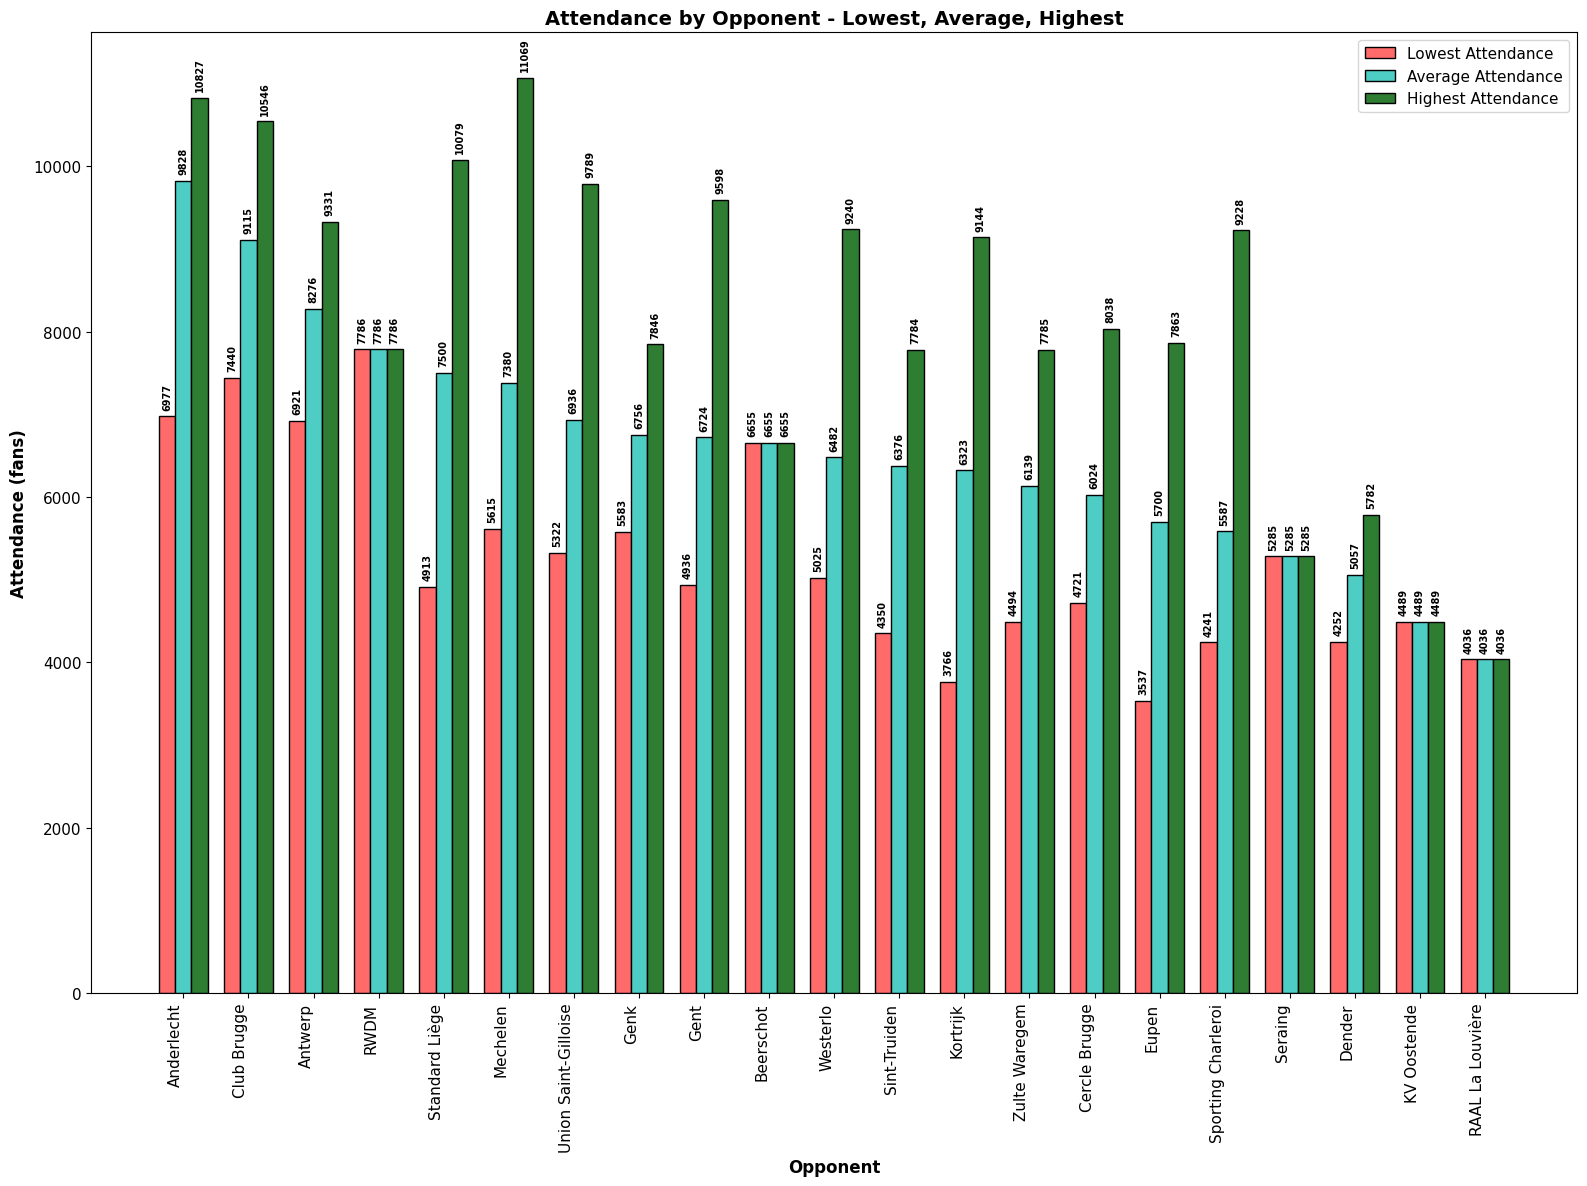


------------------------------------------------------------
OPPONENT ATTENDANCE - PERCENTAGE DIFFERENCES
------------------------------------------------------------
Overall average attendance: 6862 fans

TOP 3 OPPONENTS (Highest Attendance):
  1. Anderlecht: 9828 fans (+43% above average, +2967 fans)
  2. Club Brugge: 9116 fans (+33% above average, +2254 fans)
  3. Antwerp: 8276 fans (+21% above average, +1415 fans)

BOTTOM 3 OPPONENTS (Lowest Attendance):
  1. RAAL La Louvière: 4036 fans (-41% below average, -2826 fans)
  2. KV Oostende: 4489 fans (-35% below average, -2373 fans)
  3. Dender: 5057 fans (-26% below average, -1805 fans)


In [366]:
# ============================================================================
# 2. ATTENDANCE BY OPPONENT - ALL TEAMS
# ============================================================================
print("\n2. ATTENDANCE BY OPPONENT - ALL TEAMS")

# Make sure df is defined (the main match dataframe with tickets_scanned)
if 'df' not in locals():
    # Load match data if not already loaded
    try:
        df = pd.read_csv('data/gold_match.csv', on_bad_lines='skip')
        df.columns = df.columns.str.strip()
        df['match_date'] = pd.to_datetime(df['match_date'], errors='coerce')
        df = df[df['is_home_match'] == True].copy()
        print(f"Loaded match data: {len(df)} home matches")
    except Exception as e:
        print(f"Error loading match data: {e}")
        df = pd.DataFrame()

# Calculate overall average if not already defined
if 'overall_avg' not in locals() and len(df) > 0:
    overall_avg = df['tickets_scanned'].mean()

# Calculate for each opponent
opponents = df['away_team'].unique()
opponent_data = []

for opponent in opponents:
    opponent_df = df[df['away_team'] == opponent]
    avg_att = opponent_df['tickets_scanned'].mean()
    min_att = opponent_df['tickets_scanned'].min()
    max_att = opponent_df['tickets_scanned'].max()
    matches = len(opponent_df)
    pct_diff = ((avg_att - overall_avg) / overall_avg) * 100
    
    opponent_data.append({
        'opponent': opponent,
        'avg': avg_att,
        'min': min_att,
        'max': max_att,
        'matches': matches,
        'pct': pct_diff
    })

# Sort by average attendance (highest first)
opponent_data.sort(key=lambda x: x['avg'], reverse=True)

print("\nEXACT ATTENDANCE NUMBERS BY OPPONENT (ALL TEAMS):")
print("-" * 85)
print(f"{'Opponent':<25} {'Average':<12} {'Min':<12} {'Max':<12} {'vs Overall':<12} {'Matches':<8}")
print("-" * 85)
for opp in opponent_data:
    print(f"{opp['opponent']:<25} {opp['avg']:.0f} fans      {opp['min']:<12} {opp['max']:<12} {opp['pct']:+.0f}%       {opp['matches']:<8}")

# Create chart with proper spacing and number labels
fig, ax = plt.subplots(figsize=(16, 12))

x = np.arange(len(opponent_data))
width = 0.25

min_vals = [opp['min'] for opp in opponent_data]
avg_vals = [opp['avg'] for opp in opponent_data]
max_vals = [opp['max'] for opp in opponent_data]

bars_min = ax.bar(x - width, min_vals, width, label='Lowest Attendance', color='#FF6B6B', edgecolor='black')
bars_avg = ax.bar(x, avg_vals, width, label='Average Attendance', color='#4ECDC4', edgecolor='black')
bars_max = ax.bar(x + width, max_vals, width, label='Highest Attendance', color='#2E7D32', edgecolor='black')

ax.set_ylabel('Attendance (fans)', fontsize=12, fontweight='bold')
ax.set_xlabel('Opponent', fontsize=12, fontweight='bold')
ax.set_title('Attendance by Opponent - Lowest, Average, Highest', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([opp['opponent'] for opp in opponent_data], rotation=90, ha='right')
ax.legend(loc='upper right')
ax.set_ylim(0, max(max_vals) * 1.05)

# Add MIN, AVG, MAX number labels on bars
for i in range(len(opponent_data)):
    if min_vals[i] > 0:
        ax.text(bars_min[i].get_x() + bars_min[i].get_width()/2, bars_min[i].get_height() + 80, 
                f'{int(min_vals[i])}', ha='center', va='bottom', fontsize=7, fontweight='bold', rotation=90)
    ax.text(bars_avg[i].get_x() + bars_avg[i].get_width()/2, bars_avg[i].get_height() + 80, 
            f'{int(avg_vals[i])}', ha='center', va='bottom', fontsize=7, fontweight='bold', rotation=90)
    if max_vals[i] > 0:
        ax.text(bars_max[i].get_x() + bars_max[i].get_width()/2, bars_max[i].get_height() + 80, 
                f'{int(max_vals[i])}', ha='center', va='bottom', fontsize=7, fontweight='bold', rotation=90)

plt.tight_layout()
save_chart('attendance_by_opponent')
plt.show()

# CLEAR PERCENTAGE SUMMARY AFTER CHART
print("\n" + "-" * 60)
print("OPPONENT ATTENDANCE - PERCENTAGE DIFFERENCES")
print("-" * 60)

print(f"Overall average attendance: {overall_avg:.0f} fans")
print("\nTOP 3 OPPONENTS (Highest Attendance):")
for i in range(3):
    opp = opponent_data[i]
    diff = opp['avg'] - overall_avg
    print(f"  {i+1}. {opp['opponent']}: {opp['avg']:.0f} fans ({opp['pct']:+.0f}% above average, +{diff:.0f} fans)")

print("\nBOTTOM 3 OPPONENTS (Lowest Attendance):")
for i in range(3):
    opp = opponent_data[-(i+1)]
    diff = opp['avg'] - overall_avg
    print(f"  {i+1}. {opp['opponent']}: {opp['avg']:.0f} fans ({opp['pct']:+.0f}% below average, {diff:.0f} fans)")


3. ATTENDANCE BY DAY OF WEEK

EXACT ATTENDANCE NUMBERS BY DAY OF WEEK:
---------------------------------------------------------------------------
Day          Average      Min          Max          vs Overall   Matches 
---------------------------------------------------------------------------
Tuesday      5700 fans      3537.0       7863.0       -17%       2       
Wednesday    7846 fans      7846.0       7846.0       +14%       1       
Friday       6360 fans      4241.0       9144.0       -7%       10      
Saturday     6695 fans      4036.0       10485.0      -2%       30      
Sunday       7266 fans      3766.0       11069.0      +6%       28      
✓ Chart saved: bar_charts/attendance_by_day_of_week.png


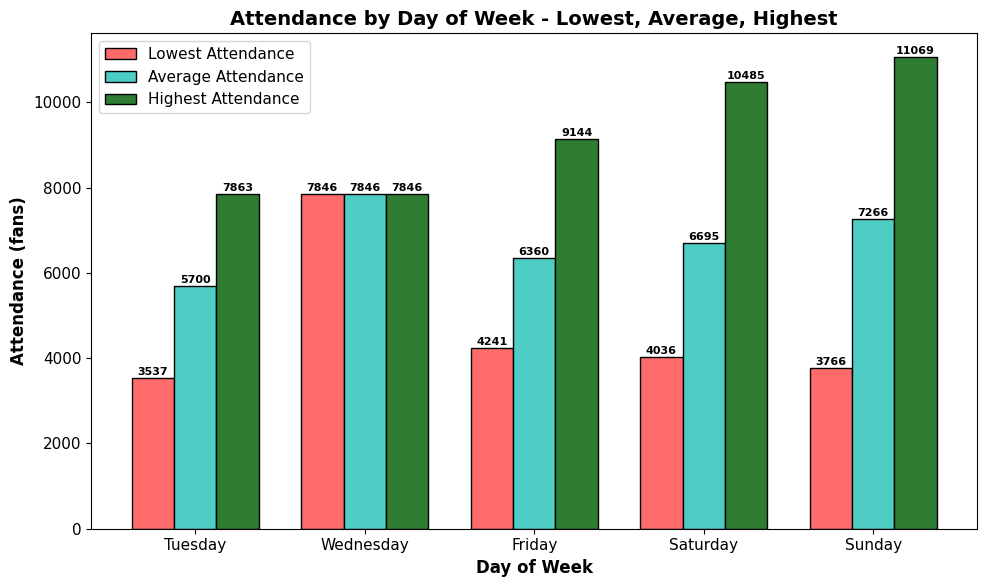


------------------------------------------------------------
DAY OF WEEK - PERCENTAGE DIFFERENCES
------------------------------------------------------------
Overall average attendance: 6862 fans

WEEKEND VS WEEKDAY:
  Weekend average: 6981 fans
  Weekday average: 6635 fans
  Weekend advantage: +5% (+345 fans)

Best Days:
  Wednesday: 7846 fans (+14% above average)
  Sunday: 7266 fans (+6% above average)

Worst Days:
  Tuesday: 5700 fans (-17% below average)
  Friday: 6360 fans (-7% below average)


In [367]:
# ============================================================================
# 3. ATTENDANCE BY DAY OF WEEK
# ============================================================================
print("\n3. ATTENDANCE BY DAY OF WEEK")

if 'day_of_week' not in df.columns:
    try:
        context_df = pd.read_csv('data/gold_match_context.csv', on_bad_lines='skip')
        context_df.columns = context_df.columns.str.strip()
        
        # Merge with main dataframe
        df = df.merge(context_df[['match_id', 'weekday_name']], on='match_id', how='left')
        
        # Rename to day_of_week
        df['day_of_week'] = df['weekday_name']
        print("Merged day_of_week from gold_match_context")
    except Exception as e:
        print(f"Error loading context data: {e}")
        # Fallback: create from match_date if available
        if 'match_date' in df.columns:
            df['day_of_week'] = df['match_date'].dt.day_name()
            print("Created day_of_week from match_date")

# Calculate data for days that actually have matches
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_data = []

for day in day_order:
    day_df = df[df['day_of_week'] == day]
    if len(day_df) > 0:
        avg_att = day_df['tickets_scanned'].mean()
        min_att = day_df['tickets_scanned'].min()
        max_att = day_df['tickets_scanned'].max()
        matches = len(day_df)
        pct_diff = ((avg_att - overall_avg) / overall_avg) * 100
        day_data.append({
            'day': day,
            'avg': avg_att,
            'min': min_att,
            'max': max_att,
            'matches': matches,
            'pct': pct_diff
        })
    # Skip days with no data

if len(day_data) > 0:
    print("\nEXACT ATTENDANCE NUMBERS BY DAY OF WEEK:")
    print("-" * 75)
    print(f"{'Day':<12} {'Average':<12} {'Min':<12} {'Max':<12} {'vs Overall':<12} {'Matches':<8}")
    print("-" * 75)
    for day in day_data:
        print(f"{day['day']:<12} {day['avg']:.0f} fans      {day['min']:<12} {day['max']:<12} {day['pct']:+.0f}%       {day['matches']:<8}")

    # Create chart with only days that have data
    valid_days = [d for d in day_data if d['matches'] > 0]
    day_names = [d['day'] for d in valid_days]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    x = np.arange(len(valid_days))
    width = 0.25
    
    min_vals = [d['min'] for d in valid_days]
    avg_vals = [d['avg'] for d in valid_days]
    max_vals = [d['max'] for d in valid_days]
    
    bars_min = ax.bar(x - width, min_vals, width, label='Lowest Attendance', color='#FF6B6B', edgecolor='black')
    bars_avg = ax.bar(x, avg_vals, width, label='Average Attendance', color='#4ECDC4', edgecolor='black')
    bars_max = ax.bar(x + width, max_vals, width, label='Highest Attendance', color='#2E7D32', edgecolor='black')
    
    ax.set_ylabel('Attendance (fans)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Day of Week', fontsize=12, fontweight='bold')
    ax.set_title('Attendance by Day of Week - Lowest, Average, Highest', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(day_names)
    ax.legend(loc='upper left')
    
    max_val = max(max_vals)
    ax.set_ylim(0, max_val * 1.05)
    
    # Add MIN, AVG, MAX number labels on bars
    for i in range(len(valid_days)):
        if min_vals[i] > 0:
            ax.text(bars_min[i].get_x() + bars_min[i].get_width()/2, bars_min[i].get_height() + 20, 
                    f'{int(min_vals[i])}', ha='center', va='bottom', fontsize=8, fontweight='bold')
        if avg_vals[i] > 0:
            ax.text(bars_avg[i].get_x() + bars_avg[i].get_width()/2, bars_avg[i].get_height() + 20, 
                    f'{int(avg_vals[i])}', ha='center', va='bottom', fontsize=8, fontweight='bold')
        if max_vals[i] > 0:
            ax.text(bars_max[i].get_x() + bars_max[i].get_width()/2, bars_max[i].get_height() + 20, 
                    f'{int(max_vals[i])}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    
    plt.tight_layout()
    save_chart('attendance_by_day_of_week')
    plt.show()
else:
    print("No day of week data available")

# CLEAR PERCENTAGE SUMMARY AFTER CHART
print("\n" + "-" * 60)
print("DAY OF WEEK - PERCENTAGE DIFFERENCES")
print("-" * 60)

print(f"Overall average attendance: {overall_avg:.0f} fans")

# Weekend vs Weekday comparison (only count days with data)
weekend_days = ['Saturday', 'Sunday']
weekend_vals = [d['avg'] for d in day_data if d['day'] in weekend_days]
weekday_vals = [d['avg'] for d in day_data if d['day'] not in weekend_days]

if len(weekend_vals) > 0 and len(weekday_vals) > 0:
    weekend_avg = sum(weekend_vals) / len(weekend_vals)
    weekday_avg = sum(weekday_vals) / len(weekday_vals)
    weekend_boost = ((weekend_avg - weekday_avg) / weekday_avg) * 100
    
    print(f"\nWEEKEND VS WEEKDAY:")
    print(f"  Weekend average: {weekend_avg:.0f} fans")
    print(f"  Weekday average: {weekday_avg:.0f} fans")
    print(f"  Weekend advantage: +{weekend_boost:.0f}% (+{weekend_avg - weekday_avg:.0f} fans)")
else:
    print("\nWEEKEND VS WEEKDAY: Insufficient data")

print("\nBest Days:")
for day in day_data:
    if day['pct'] > 5:
        print(f"  {day['day']}: {day['avg']:.0f} fans ({day['pct']:+.0f}% above average)")

print("\nWorst Days:")
for day in day_data:
    if day['pct'] < -5:
        print(f"  {day['day']}: {day['avg']:.0f} fans ({day['pct']:+.0f}% below average)")


4. ATTENDANCE BY KICKOFF TIME

EXACT ATTENDANCE NUMBERS BY KICKOFF TIME:
-------------------------------------------------------------------------------------
Kickoff Time                 Average      Min          Max          vs Overall   Matches 
-------------------------------------------------------------------------------------
Early Evening (15:00-18:00)      7247 fans       3537      11069        +6%     46
Evening (18:00-20:00)            6251 fans       4241       9144        -9%     24
Late Evening (after 20:00)       3766 fans       3766       3766       -45%      1
✓ Chart saved: bar_charts/attendance_by_kickoff_time.png


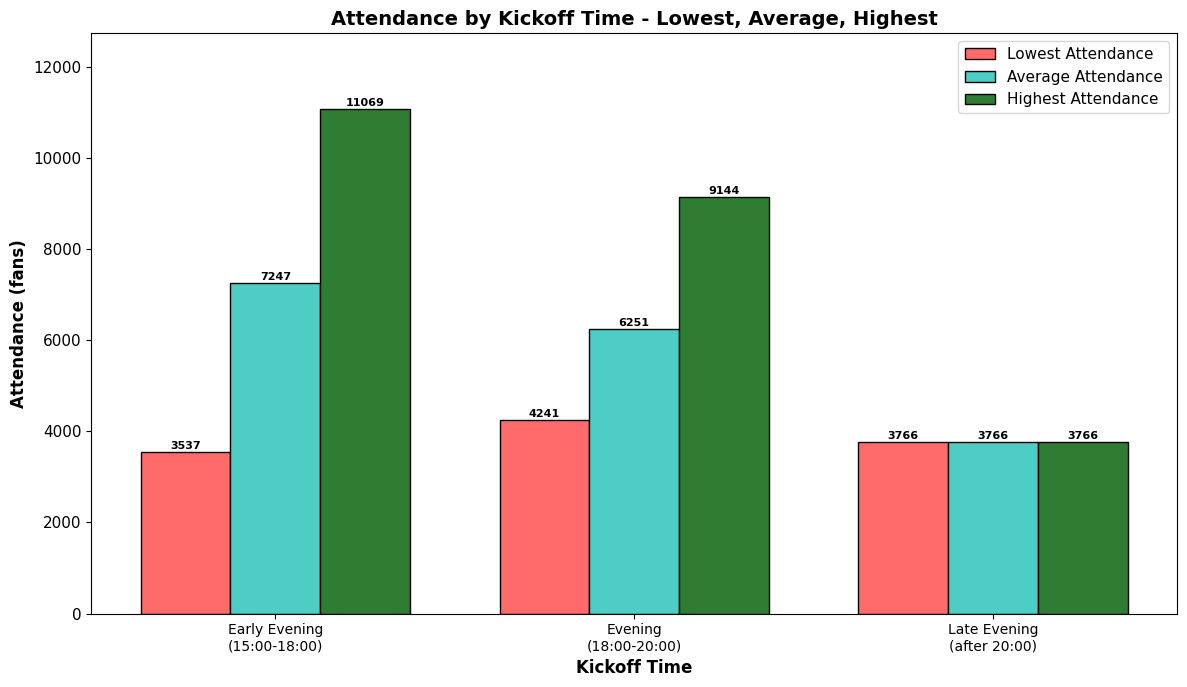


------------------------------------------------------------
KICKOFF TIME - PERCENTAGE DIFFERENCES
------------------------------------------------------------
Overall average attendance: 6862 fans

Best Kickoff Times (Above Average):
  Early Evening (15:00-18:00): 7247 fans (+6% above average, +386 fans)

Worst Kickoff Times (Below Average):
  Evening (18:00-20:00): 6251 fans (-9% below average, -610 fans)
  Late Evening (after 20:00): 3766 fans (-45% below average, -3096 fans)

BEST VS WORST:
  Best: Early Evening (15:00-18:00) - 7247 fans
  Worst: Late Evening (after 20:00) - 3766 fans
  Difference: 3481 fans


In [368]:
# ============================================================================
# 4. ATTENDANCE BY KICKOFF TIME
# ============================================================================
print("\n4. ATTENDANCE BY KICKOFF TIME")

# First, ensure kickoff_hour is calculated
if 'kickoff_hour' not in df.columns:
    if 'kickoff_time_local' in df.columns:
        df['kickoff_time_local'] = df['kickoff_time_local'].fillna('20:00')
        df['kickoff_hour'] = df['kickoff_time_local'].str.split(':').str[0].astype(float)
        print("Created kickoff_hour from kickoff_time_local")
    else:
        print("Error: kickoff_time_local not found")

# Create time categories with proper two-line labels
df['time_category'] = pd.cut(df['kickoff_hour'], 
                               bins=[0, 12, 15, 18, 20, 24],
                               labels=['Morning\n(before 12:00)', 
                                      'Afternoon\n(12:00-15:00)', 
                                      'Early Evening\n(15:00-18:00)', 
                                      'Evening\n(18:00-20:00)', 
                                      'Late Evening\n(after 20:00)'])

time_order = ['Morning\n(before 12:00)', 'Afternoon\n(12:00-15:00)', 
              'Early Evening\n(15:00-18:00)', 'Evening\n(18:00-20:00)', 
              'Late Evening\n(after 20:00)']

time_data = []

for time in time_order:
    time_df = df[df['time_category'] == time]
    if len(time_df) > 0:
        avg_att = time_df['tickets_scanned'].mean()
        min_att = time_df['tickets_scanned'].min()
        max_att = time_df['tickets_scanned'].max()
        matches = len(time_df)
        pct_diff = ((avg_att - overall_avg) / overall_avg) * 100
        time_data.append({
            'time': time,
            'avg': avg_att,
            'min': min_att,
            'max': max_att,
            'matches': matches,
            'pct': pct_diff
        })
    # Skip times with no data

if len(time_data) > 0:
    print("\nEXACT ATTENDANCE NUMBERS BY KICKOFF TIME:")
    print("-" * 85)
    print(f"{'Kickoff Time':<28} {'Average':<12} {'Min':<12} {'Max':<12} {'vs Overall':<12} {'Matches':<8}")
    print("-" * 85)
    for time in time_data:
        time_display = time['time'].replace('\n', ' ')
        print(f"{time_display:<28} {time['avg']:>8.0f} fans   {time['min']:>8.0f}   {time['max']:>8.0f}   {time['pct']:>+7.0f}%   {time['matches']:>4}")

    # Create bar chart with only times that have data
    valid_times = [t for t in time_data if t['matches'] > 0]
    
    fig, ax = plt.subplots(figsize=(12, 7))
    
    x = np.arange(len(valid_times))
    width = 0.25
    
    min_vals = [t['min'] for t in valid_times]
    avg_vals = [t['avg'] for t in valid_times]
    max_vals = [t['max'] for t in valid_times]
    
    bars_min = ax.bar(x - width, min_vals, width, label='Lowest Attendance', color='#FF6B6B', edgecolor='black')
    bars_avg = ax.bar(x, avg_vals, width, label='Average Attendance', color='#4ECDC4', edgecolor='black')
    bars_max = ax.bar(x + width, max_vals, width, label='Highest Attendance', color='#2E7D32', edgecolor='black')
    
    ax.set_ylabel('Attendance (fans)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Kickoff Time', fontsize=12, fontweight='bold')
    ax.set_title('Attendance by Kickoff Time - Lowest, Average, Highest', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([t['time'] for t in valid_times], fontsize=10)
    ax.legend(loc='upper right')
    
    max_val = max(max_vals)
    ax.set_ylim(0, max_val * 1.15)
    
    # Add MIN, AVG, MAX number labels on bars
    for i in range(len(valid_times)):
        if min_vals[i] > 0:
            ax.text(bars_min[i].get_x() + bars_min[i].get_width()/2, bars_min[i].get_height() + 20, 
                    f'{int(min_vals[i])}', ha='center', va='bottom', fontsize=8, fontweight='bold')
        if avg_vals[i] > 0:
            ax.text(bars_avg[i].get_x() + bars_avg[i].get_width()/2, bars_avg[i].get_height() + 20, 
                    f'{int(avg_vals[i])}', ha='center', va='bottom', fontsize=8, fontweight='bold')
        if max_vals[i] > 0:
            ax.text(bars_max[i].get_x() + bars_max[i].get_width()/2, bars_max[i].get_height() + 20, 
                    f'{int(max_vals[i])}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    
    plt.tight_layout()
    save_chart('attendance_by_kickoff_time')
    plt.show()
else:
    print("No kickoff time data available")

# CLEAR PERCENTAGE SUMMARY AFTER CHART
print("\n" + "-" * 60)
print("KICKOFF TIME - PERCENTAGE DIFFERENCES")
print("-" * 60)

print(f"Overall average attendance: {overall_avg:.0f} fans")

if len(time_data) > 0:
    print("\nBest Kickoff Times (Above Average):")
    for time in time_data:
        if time['pct'] > 0:
            time_name = time['time'].replace('\n', ' ')
            print(f"  {time_name}: {time['avg']:.0f} fans ({time['pct']:+.0f}% above average, +{time['avg'] - overall_avg:.0f} fans)")

    print("\nWorst Kickoff Times (Below Average):")
    for time in time_data:
        if time['pct'] < 0:
            time_name = time['time'].replace('\n', ' ')
            print(f"  {time_name}: {time['avg']:.0f} fans ({time['pct']:+.0f}% below average, {time['avg'] - overall_avg:.0f} fans)")

    # Find best and worst
    best_time = max(time_data, key=lambda x: x['avg'])
    worst_time = min(time_data, key=lambda x: x['avg'])
    best_name = best_time['time'].replace('\n', ' ')
    worst_name = worst_time['time'].replace('\n', ' ')
    print(f"\nBEST VS WORST:")
    print(f"  Best: {best_name} - {best_time['avg']:.0f} fans")
    print(f"  Worst: {worst_name} - {worst_time['avg']:.0f} fans")
    print(f"  Difference: {best_time['avg'] - worst_time['avg']:.0f} fans")
else:
    print("No kickoff time data available for comparison")


5. ATTENDANCE BY PROMOTION CATEGORY
Error: 'match_id'

PROMOTION CATEGORY DISTRIBUTION:
------------------------------------------------------------
  No Promotion: 45 matches
  RBFA Federation Cards: 12 matches
  Free Ticket for Subscribers: 6 matches
  50% Discount: 3 matches
  1+1 Promotion: 2 matches
  Valentine's Day: 1 matches
  Other Promotion: 1 matches
  Bring a Friend: 1 matches

EXACT ATTENDANCE NUMBERS BY PROMOTION CATEGORY:
-----------------------------------------------------------------------------------------------
Promotion Category             Average      Min          Max          vs Overall   Matches 
-----------------------------------------------------------------------------------------------
No Promotion                   7345 fans      3537.0       11069.0      +7%       45      
50% Discount                   6882 fans      5907.0       8038.0       +0%       3       
1+1 Promotion                  6455 fans      3766.0       9144.0       -6%       2       
B

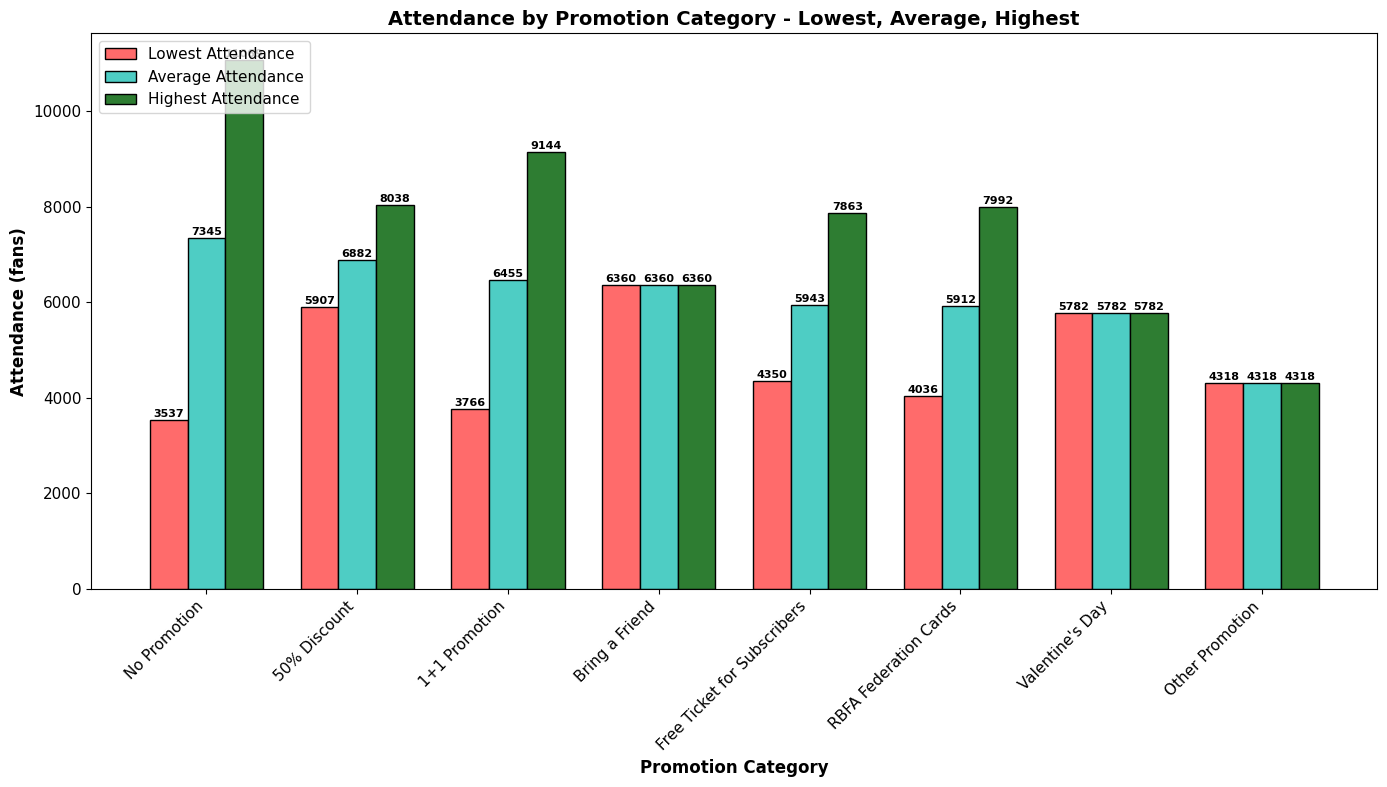


------------------------------------------------------------
PROMOTION CATEGORIES - PERCENTAGE DIFFERENCES
------------------------------------------------------------
Overall average attendance: 6862 fans

Best Performing Promotions (Above Average):
  50% Discount: 6882 fans (+0% above average, +20 fans)

Worst Performing Promotions (Below Average):
  1+1 Promotion: 6455 fans (-6% below average, -407 fans)
  Bring a Friend: 6360 fans (-7% below average, -502 fans)
  Free Ticket for Subscribers: 5944 fans (-13% below average, -918 fans)
  RBFA Federation Cards: 5913 fans (-14% below average, -949 fans)
  Valentine's Day: 5782 fans (-16% below average, -1080 fans)
  Other Promotion: 4318 fans (-37% below average, -2544 fans)

COMPARED TO NO PROMOTION (7345 fans):
  50% Discount: 6882 fans (-6% vs no promotion, +-463 fans)
  1+1 Promotion: 6455 fans (-12% vs no promotion, +-890 fans)
  Bring a Friend: 6360 fans (-13% vs no promotion, +-985 fans)
  Free Ticket for Subscribers: 5944 fans 

In [369]:
# ============================================================================
# 5. ATTENDANCE BY PROMOTION CATEGORY
# ============================================================================
print("\n5. ATTENDANCE BY PROMOTION CATEGORY")

# Load and merge promotion data
try:
    context_df = pd.read_csv('data/gold_match_context.csv', on_bad_lines='skip')
    context_df.columns = context_df.columns.str.strip()
    
    # Drop existing promotion columns to avoid duplicates
    existing_promo_cols = []
    for col in context_df.columns:
        if 'promotion' in col.lower() or 'promo' in col.lower():
            if col in df.columns:
                existing_promo_cols.append(col)
    
    if existing_promo_cols:
        df = df.drop(columns=existing_promo_cols, errors='ignore')
    
    if 'pct_free_tickets' in df.columns:
        df = df.drop(columns=['pct_free_tickets'], errors='ignore')
    
    # Merge promotion columns
    promo_cols = ['match_id', 'has_promotion', 'promotion_names', 'promo_tickets_total', 
                  'pct_free_tickets', 'promo_valentijn_tickets', 'promo_1plus1_tickets',
                  'promo_bring_a_friend_tickets', 'promo_free_subscriber_tickets',
                  'promo_bondskaarten_tickets', 'promo_discount_tickets']
    
    existing_cols = [c for c in promo_cols if c in context_df.columns]
    df = df.merge(context_df[existing_cols], on='match_id', how='left')
    
    # Fill NaN values
    for col in existing_cols:
        if col != 'match_id' and col in df.columns:
            if 'tickets' in col or 'pct' in col:
                df[col] = df[col].fillna(0)
            else:
                df[col] = df[col].fillna('')
    
except Exception as e:
    print(f"Error: {e}")

# Define promotion categories based on actual promotion names
def get_promotion_category(promo_names):
    if pd.isna(promo_names) or promo_names == '' or promo_names == 'nan':
        return 'No Promotion'
    promo_names = str(promo_names).lower()
    
    if '1+1' in promo_names:
        return '1+1 Promotion'
    elif 'gratis ticket abonnee' in promo_names or 'gratis ticket halfseizoensabonnee' in promo_names:
        return 'Free Ticket for Subscribers'
    elif 'gratis ticket' in promo_names:
        return 'Free Ticket'
    elif '50% korting' in promo_names or '50% discount' in promo_names:
        return '50% Discount'
    elif 'bondskaarten' in promo_names:
        return 'RBFA Federation Cards'
    elif 'werknemers' in promo_names:
        return 'Employee Discount'
    elif 'abonnement' in promo_names:
        return 'Season Ticket Promotion'
    elif 'halfseizoensabo' in promo_names:
        return 'Half Season Ticket'
    elif 'valentijn' in promo_names:
        return 'Valentine\'s Day'
    elif 'bring a friend' in promo_names:
        return 'Bring a Friend'
    else:
        return 'Other Promotion'

# Apply categorization
if 'promotion_names' in df.columns:
    df['promotion_names'] = df['promotion_names'].fillna('')
    df['promotion_category'] = df['promotion_names'].apply(get_promotion_category)
    
    if 'has_promotion' in df.columns:
        df.loc[df['has_promotion'] == False, 'promotion_category'] = 'No Promotion'
    
    print("\nPROMOTION CATEGORY DISTRIBUTION:")
    print("-" * 60)
    category_counts = df['promotion_category'].value_counts()
    for cat, count in category_counts.items():
        print(f"  {cat}: {count} matches")
else:
    df['promotion_category'] = 'No Promotion'
    print("All matches set to 'No Promotion'")

# Calculate attendance by promotion category
promo_categories = df['promotion_category'].unique()
promo_category_data = []

for category in promo_categories:
    cat_df = df[df['promotion_category'] == category]
    if len(cat_df) > 0:
        avg_att = cat_df['tickets_scanned'].mean()
        min_att = cat_df['tickets_scanned'].min()
        max_att = cat_df['tickets_scanned'].max()
        matches = len(cat_df)
        pct_diff = ((avg_att - overall_avg) / overall_avg) * 100
        
        promo_category_data.append({
            'category': category,
            'avg': avg_att,
            'min': min_att,
            'max': max_att,
            'matches': matches,
            'pct': pct_diff
        })

if len(promo_category_data) > 0:
    # Sort by average attendance (highest first)
    promo_category_data.sort(key=lambda x: x['avg'], reverse=True)
    
    print("\nEXACT ATTENDANCE NUMBERS BY PROMOTION CATEGORY:")
    print("-" * 95)
    print(f"{'Promotion Category':<30} {'Average':<12} {'Min':<12} {'Max':<12} {'vs Overall':<12} {'Matches':<8}")
    print("-" * 95)
    for cat in promo_category_data:
        print(f"{cat['category']:<30} {cat['avg']:.0f} fans      {cat['min']:<12} {cat['max']:<12} {cat['pct']:+.0f}%       {cat['matches']:<8}")
    
    # Create chart
    fig, ax = plt.subplots(figsize=(14, 8))
    
    x = np.arange(len(promo_category_data))
    width = 0.25
    
    min_vals = [cat['min'] for cat in promo_category_data]
    avg_vals = [cat['avg'] for cat in promo_category_data]
    max_vals = [cat['max'] for cat in promo_category_data]
    
    bars_min = ax.bar(x - width, min_vals, width, label='Lowest Attendance', color='#FF6B6B', edgecolor='black')
    bars_avg = ax.bar(x, avg_vals, width, label='Average Attendance', color='#4ECDC4', edgecolor='black')
    bars_max = ax.bar(x + width, max_vals, width, label='Highest Attendance', color='#2E7D32', edgecolor='black')
    
    ax.set_ylabel('Attendance (fans)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Promotion Category', fontsize=12, fontweight='bold')
    ax.set_title('Attendance by Promotion Category - Lowest, Average, Highest', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([cat['category'] for cat in promo_category_data], rotation=45, ha='right')
    ax.legend(loc='upper left')
    
    max_val = max(max_vals)
    ax.set_ylim(0, max_val * 1.05)
    
    # Add MIN, AVG, MAX number labels on bars
    for i in range(len(promo_category_data)):
        if min_vals[i] > 0:
            ax.text(bars_min[i].get_x() + bars_min[i].get_width()/2, bars_min[i].get_height() + 20, 
                    f'{int(min_vals[i])}', ha='center', va='bottom', fontsize=8, fontweight='bold')
        if avg_vals[i] > 0:
            ax.text(bars_avg[i].get_x() + bars_avg[i].get_width()/2, bars_avg[i].get_height() + 20, 
                    f'{int(avg_vals[i])}', ha='center', va='bottom', fontsize=8, fontweight='bold')
        if max_vals[i] > 0:
            ax.text(bars_max[i].get_x() + bars_max[i].get_width()/2, bars_max[i].get_height() + 20, 
                    f'{int(max_vals[i])}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    
    plt.tight_layout()
    save_chart('attendance_by_promotion_category')
    plt.show()
    
    # CLEAR PERCENTAGE SUMMARY AFTER CHART
    print("\n" + "-" * 60)
    print("PROMOTION CATEGORIES - PERCENTAGE DIFFERENCES")
    print("-" * 60)
    
    print(f"Overall average attendance: {overall_avg:.0f} fans")
    
    # Find No Promotion baseline
    no_promo_cats = [c for c in promo_category_data if c['category'] == 'No Promotion']
    if no_promo_cats:
        no_promo = no_promo_cats[0]
        
        print("\nBest Performing Promotions (Above Average):")
        for cat in promo_category_data:
            if cat['pct'] > 0 and cat['category'] != 'No Promotion':
                diff = cat['avg'] - overall_avg
                print(f"  {cat['category']}: {cat['avg']:.0f} fans ({cat['pct']:+.0f}% above average, +{diff:.0f} fans)")
        
        print("\nWorst Performing Promotions (Below Average):")
        for cat in promo_category_data:
            if cat['pct'] < 0 and cat['category'] != 'No Promotion':
                diff = cat['avg'] - overall_avg
                print(f"  {cat['category']}: {cat['avg']:.0f} fans ({cat['pct']:+.0f}% below average, {diff:.0f} fans)")
        
        print(f"\nCOMPARED TO NO PROMOTION ({no_promo['avg']:.0f} fans):")
        for cat in promo_category_data:
            if cat['category'] != 'No Promotion':
                diff_vs_no = cat['avg'] - no_promo['avg']
                pct_vs_no = (diff_vs_no / no_promo['avg']) * 100
                print(f"  {cat['category']}: {cat['avg']:.0f} fans ({pct_vs_no:+.0f}% vs no promotion, +{diff_vs_no:.0f} fans)")
    else:
        print("No 'No Promotion' baseline found")
        
    # Show promotion ticket counts
    print("\n" + "-" * 60)
    print("PROMOTION TICKET COUNTS")
    print("-" * 60)
    if 'promo_tickets_total' in df.columns:
        print(f"Total promoted tickets: {df['promo_tickets_total'].sum():.0f}")
    if 'pct_free_tickets' in df.columns:
        print(f"Average free tickets: {df['pct_free_tickets'].mean():.1f}%")
    
    # Show specific promotion ticket breakdown
    print("\nPromotion Ticket Breakdown:")
    if 'promo_1plus1_tickets' in df.columns:
        print(f"  1+1 Promotion tickets: {df['promo_1plus1_tickets'].sum():.0f}")
    if 'promo_free_subscriber_tickets' in df.columns:
        print(f"  Free Subscriber tickets: {df['promo_free_subscriber_tickets'].sum():.0f}")
    if 'promo_bondskaarten_tickets' in df.columns:
        print(f"  RBFA Federation tickets: {df['promo_bondskaarten_tickets'].sum():.0f}")
    if 'promo_discount_tickets' in df.columns:
        print(f"  Discount tickets: {df['promo_discount_tickets'].sum():.0f}")
    
else:
    print("No promotion category data available")


BAR CHART 2: Ticket Metrics by Promotion Category (Without Season Pass Holders)

TICKET METRICS BY PROMOTION CATEGORY (Without Season Pass Holders):
-----------------------------------------------------------------------------------------------
Promotion Category             Sold       Total      Scanned    No-Show    Matches 
-----------------------------------------------------------------------------------------------
No Promotion                   6670       6670       7345       -10%       45      
50% Discount                   6958       6958       6882       1%       3       
1+1 Promotion                  6212       6212       6455       1%       2       
Bring a Friend                 7749       7749       6360       18%       1       
Free Ticket for Subscribers    6683       6683       5944       10%       6       
RBFA Federation Cards          6606       6606       5913       17%       12      
Valentine's Day                7743       7743       5782       25%       1  

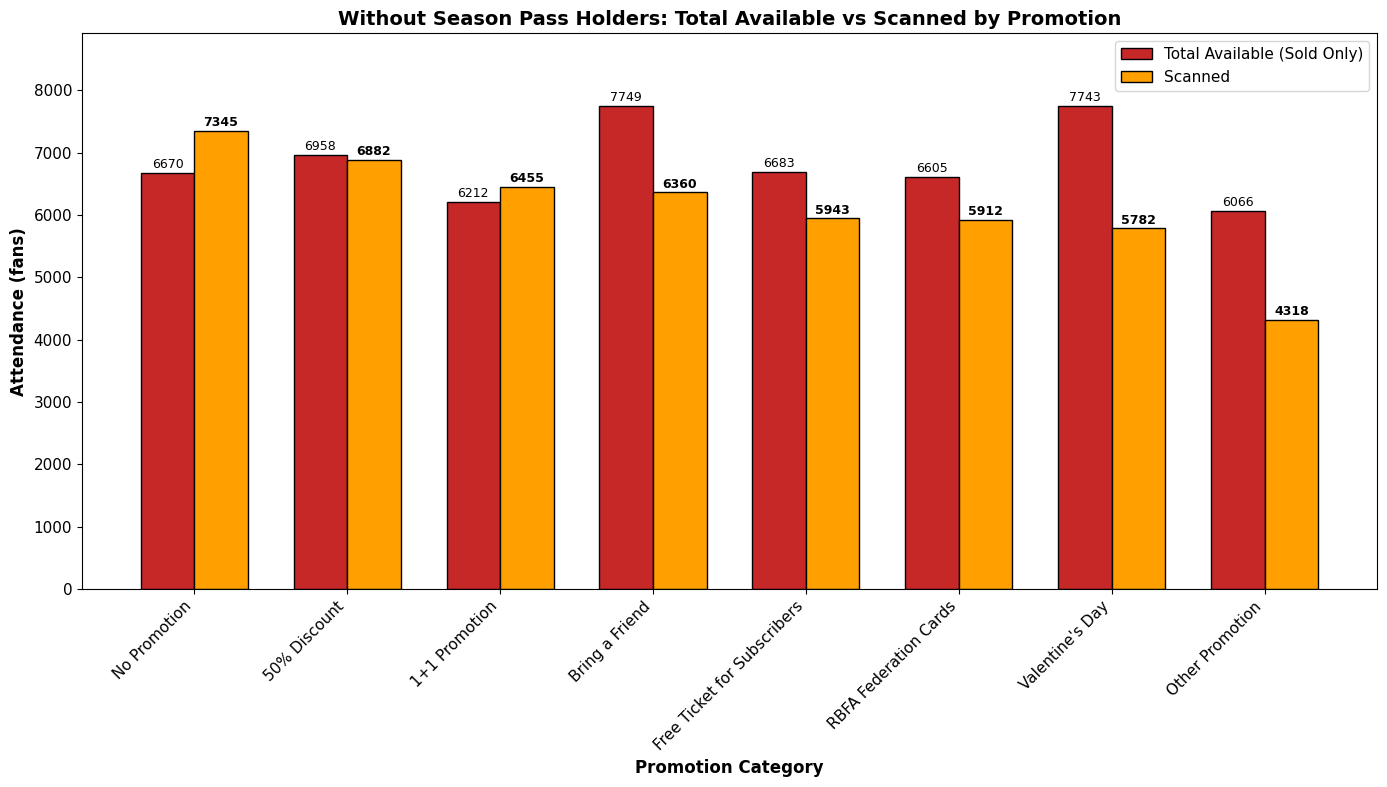


NO-SHOW RATE ANALYSIS (Without Season Pass Holders)

Overall average no-show rate: -1.6%

No-Show Rate by Promotion Category:
  No Promotion: -10.0% no-show rate (45 matches)
  50% Discount: 0.6% no-show rate (3 matches)
  1+1 Promotion: 0.7% no-show rate (2 matches)
  Bring a Friend: 17.9% no-show rate (1 matches)
  Free Ticket for Subscribers: 9.9% no-show rate (6 matches)
  RBFA Federation Cards: 17.1% no-show rate (12 matches)
  Valentine's Day: 25.3% no-show rate (1 matches)
  Other Promotion: 28.8% no-show rate (1 matches)


In [370]:
# ============================================================================
# BAR CHART 2: Ticket Metrics by Promotion Category (WITHOUT Season Pass Holders)
# ============================================================================
print("\nBAR CHART 2: Ticket Metrics by Promotion Category (Without Season Pass Holders)")

# Calculate total available without season pass holders
df['total_available_without_season'] = df['tickets_sold_total']
df['no_show_rate_without_season'] = 0
mask = df['total_available_without_season'] > 0
df.loc[mask, 'no_show_rate_without_season'] = (df.loc[mask, 'total_available_without_season'] - 
                                                 df.loc[mask, 'tickets_scanned']) / df.loc[mask, 'total_available_without_season']

# Calculate metrics by promotion category (without season pass holders)
promo_ticket_data_without = []

for cat in promo_category_data:
    category = cat['category']
    cat_df = df[df['promotion_category'] == category]
    
    if len(cat_df) > 0:
        promo_ticket_data_without.append({
            'category': category,
            'sold': cat_df['tickets_sold_total'].mean(),
            'total': cat_df['total_available_without_season'].mean(),
            'scanned': cat_df['tickets_scanned'].mean(),
            'no_show': cat_df['no_show_rate_without_season'].mean() * 100,
            'matches': len(cat_df)
        })

promo_ticket_df_without = pd.DataFrame(promo_ticket_data_without).sort_values('scanned', ascending=False)

print("\nTICKET METRICS BY PROMOTION CATEGORY (Without Season Pass Holders):")
print("-" * 95)
print(f"{'Promotion Category':<30} {'Sold':<10} {'Total':<10} {'Scanned':<10} {'No-Show':<10} {'Matches':<8}")
print("-" * 95)
for _, row in promo_ticket_df_without.iterrows():
    print(f"{row['category']:<30} {row['sold']:.0f}{' ':<6} {row['total']:.0f}{' ':<6} {row['scanned']:.0f}{' ':<6} {row['no_show']:.0f}%{' ':<6} {row['matches']:<8}")

# Create bar chart - Total Available vs Scanned (Without Season Pass Holders)
fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(promo_ticket_df_without))
width = 0.35

total_vals = promo_ticket_df_without['total'].values
scanned_vals = promo_ticket_df_without['scanned'].values

bars_total = ax.bar(x - width/2, total_vals, width, label='Total Available (Sold Only)', color='#C62828', edgecolor='black')
bars_scanned = ax.bar(x + width/2, scanned_vals, width, label='Scanned', color='#FFA000', edgecolor='black')

ax.set_ylabel('Attendance (fans)', fontsize=12, fontweight='bold')
ax.set_xlabel('Promotion Category', fontsize=12, fontweight='bold')
ax.set_title('Without Season Pass Holders: Total Available vs Scanned by Promotion', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(promo_ticket_df_without['category'], rotation=45, ha='right')
ax.legend()

max_val = max(total_vals.max(), scanned_vals.max())
ax.set_ylim(0, max_val * 1.15)

# Add value labels
for bar, val in zip(bars_total, total_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30, f'{int(val)}', 
            ha='center', va='bottom', fontsize=9)
for bar, val in zip(bars_scanned, scanned_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30, f'{int(val)}', 
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
save_chart('attendance_by_promotion_category_without_season_pass')
plt.show()

# No-show rate analysis (without season pass holders)
print("\n" + "=" * 80)
print("NO-SHOW RATE ANALYSIS (Without Season Pass Holders)")
print("=" * 80)
print(f"\nOverall average no-show rate: {df['no_show_rate_without_season'].mean()*100:.1f}%")
print("\nNo-Show Rate by Promotion Category:")
for _, row in promo_ticket_df_without.iterrows():
    print(f"  {row['category']}: {row['no_show']:.1f}% no-show rate ({row['matches']} matches)")